<a href="https://colab.research.google.com/github/Misganw/Ethiopian_Traffic_Sign_Recognation/blob/main/Traffic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/My\ Drive/traffic/

/content/drive/My Drive/traffic


In [ ]:
!pip install ipython-autotime
%load_ext autotime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 32.3 MB/s eta 0:00:00
time: 264 µs (started: 2026-03-14 12:01:44 +00:00)


In [ ]:
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Activation,BatchNormalization
from keras.layers import Conv2D, MaxPooling2D
# from keras.utils import to_categorical
from keras.preprocessing import image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
# from tqdm import tqdm
%matplotlib inline

from tensorflow.keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input
from tensorflow.keras.applications.mobilenet import MobileNet
from keras.applications.mobilenet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras import regularizers, optimizers
from tensorflow.keras.optimizers import Adam,Adamax,RMSprop,Adagrad,Adadelta,SGD
# import seaborn as sns

In [ ]:
!apt-get install fonts-noto

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-noto-cjk fonts-noto-cjk-extra fonts-noto-color-emoji fonts-noto-core
  fonts-noto-extra fonts-noto-mono fonts-noto-ui-core fonts-noto-ui-extra
  fonts-noto-unhinted
The following NEW packages will be installed:
  fonts-noto fonts-noto-cjk fonts-noto-cjk-extra fonts-noto-color-emoji
  fonts-noto-core fonts-noto-extra fonts-noto-mono fonts-noto-ui-core
  fonts-noto-ui-extra fonts-noto-unhinted
0 upgraded, 10 newly installed, 0 to remove and 42 not upgraded.
Need to get 317 MB of archives.
After this operation, 790 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-noto-core all 20201225-1build1 [12.2 MB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-noto all 20201225-1build1 [16.8 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-noto-cjk all 1:

In [ ]:
# === Ensure directory exists ===
!mkdir -p /usr/share/fonts/truetype/noto/

# === Remove any old versions ===
!rm -f /usr/share/fonts/truetype/noto/NotoSansEthiopic-Regular.ttf
!rm -f /usr/share/fonts/truetype/noto/NotoSans-Regular.ttf

# === Download both fonts ===
!wget -q https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansEthiopic/NotoSansEthiopic-Regular.ttf -O /usr/share/fonts/truetype/noto/NotoSansEthiopic-Regular.ttf
!wget -q https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSans/NotoSans-Regular.ttf -O /usr/share/fonts/truetype/noto/NotoSans-Regular.ttf

# === Refresh font cache ===
!fc-cache -fv > /dev/null

In [ ]:
train = pd.read_csv('/content/drive/My Drive/traffic/traffic11000.csv')    # reading the csv file
# train.head()      # printing first five rows of the file
pd.set_option('display.max_columns', None)
train

,image,tags,ለብስክሌት_ብቻ_የተፈቀደ_ነው,የአደባባዩን_ግራ_ይዘህ_ንዳ,የአደባባዩን_ቀኝ_ይዘህ_ንዳ,በመንገዱ_ላይ_የተፈቀደ_አነስተኛ_ፍጥነት_መጨረሻ,ፍንዳታ_ለሚያስከትል_ጭነት_የተፈቀደ,በግራ_በኩል_ያሽከርክሩ,በቀኝ_በኩል_ያሽከርክሩ,የጭነት_ተሽከርካሪ_መተላለፊያ,አደባባይ_መኖሩን_የሚገልጽ,የተፈቀደ_አነስተኛ_የፍጥነት_መጠን,የመኪና_ማቆሚያን_የሚገልጽ,በቀስት_በተጠቆመው_አቅጣጫ_ቀጥል,ወደ_ግራ_ታጠፍ,ተሸከርካሪዎች_ወደ_ተመሳሳይ_መዳረሻ_ለመጓዝ_በሁለቱም_በኩል_ሊያልፉ_ይችላሉ,ለአንድ_መስመር_ከተቀመጠው_አነስተኛ_ፍጥነት_በላይ_ማሽከርከርን_የሚያስገድድ,በተለያየ_መስመር_ውስጥ_ተፈጻሚ_እንድሆን_የተቀመጠ_አነስተኛ_የፍጥነት_ወሰን,በተለያየ_መስመር_ውስጥ_ተፈጻሚ_እንድሆን_የተቀመ_የፍጥነት_ወሰን,አልጋ_መኖሩን_የሚገልጽ,የእግረኛ_መንገድ,አንድ_ማይል_ርቀት_ወደ_ፓርኪንግ_ቦታ,የመመገቢያ_ቦታ,መሙያ_ጣቢያ,የመጀመሪያ_እርዳታን_የሚገልጽ,ሆስፒታል,መረጃ_ቤት,መዝናኛ_ወይም_ቡና_ቤት_መኖሩን_የሚገልጽ,የመኪና_ማቆሚያ_ቦታ_ከድንገተኛ_ስልክ_ጋር,የመኪና_ማቆሚያ_ቦታ,የጥገና_ቦታ,በዚህ_ለተሽከርካሪ_ትራፊክ_መንገድ_የለም,ለተሽከርካ_ትራፊክ_መንገድ_የለም,የአንድ_መንገድ_ትራፊክ,የህዝብ_ቴሌፎን,የጥገና_ፋሲሊቲ,የክፍያ_ዳስ_ምልክት,የቱሪስት_እረፍት_ወይም_አካባቢ,የጭነት_መኝታ_ምልክት,መንቃት_እዚህ_ይጀመራል,የክብደት_ገደብ,ደንበኞች,የቅድሚያ_መንገዱ_መጨረሻ,የመጨረሻ_ከተማ_ፍጥነት_ገደብ,ባዶ_መንገድ_ስጥ,ለሚመጡ_ተሽከርካሪዎች_መንገድ_ስጥ,መንገድ_ስጥ,በእንስሳት_የሚነዱ_ጋሪዎች_የሉም,ምንም_ሳይክል_የለም,መግቢያ_የለም,ፈንጂዎች_የሉም,ከተጠቆመው_ክብደት_በላይ_ምንም_ዕቃ_የለም,በእጅ_የሚነዳ_ጋሪ_የለም,ጥሩምባ_የለም,ወደ_ግራ_መታጠፍ_የተከለከለ,ለተጫነ_ተሽከርካሪ_ማለፍ_የለም,ምንም_ተሽከርካሪ_ከሶሎ_ሞተር_ሳይክል_በስተቀር,ምንም_ሞተር_ተሽከርካሪ,ከሁለት_እግር_በላይ_ያላቸው_ተሽከርካሪዎች_መቅደም_የተከለከለ,የመኪና_ማቆሚያ_የለም,እግረኞች_የሉም,ወደ_ቀኝ_መታጠፍ_የተከለከለ,ብቸኛ_ሞተር_ሳይክል_የለም,ማቆም_የለም,የሚጎተት_መኪና_የለም,የተጎተቱ_ካራቫስ_የለም,የከተማ_ክልል,ወደ_ዩ_ግራ_መታጠፍ_የለም,ወደ_ዩ_ቀኝ_መታጠፍ_የለም,ምንም_የተሽከርካሪ_እጀታ_ጭነት_በላይ_አልተገለጸም,ከኸያ_ቶን_በላይ_ተሽከርካሪ_የተከለከለ,ተሽከርካሪ_የለም,ከከፍተኛው_ወርድ_በላይ_ምንም_ተሽከርካሪ_አይታይም,ከተገለጸው_ርዝመት_በላይ_የተከለከለ,ከሚታየው_ ከፍታ_በላይ_ምንም_ተሽከርካሪ_ማለፍ_አይችልም,የመጠበቅ_መጨረሻ,አይጠበቅም,ቅድሚያ_መንገድ,ገደብ_አልቋል,መስቀለኛ_መንገድ_ከመግባትህ_በፊት_አቁም,አቁም,ከፍተኛው_ፍጥነት,መኪና_አለ,ወደግራ_ታጠፍ,ወደ_ቀኝ_ታጠፍ,ጋሪዎች_ከፊት_አሉ,የቁልቁል_ማርከሮች,መስቀለኛ_መንገድ,የአካል_ጉዳተኛ_ሰው,ድርብ_ታጠፍ,ድርብ_ቁልቁል_ማርከሮች,በጥንቃቄ_መንዳት,የአስፋልት_መንገድ_መጨረሻ,የድልድይ_ግድግዳ_መጨረሻ,የሁለት_ጋሪ_መንገድ_መጨረሻ,በሁለት_የተከፈለ_መንገድ_መጨረሻ,የእርሻ_ማሽን_የሚገልጽ_አንድ,የእርሻ_ማሽን_የሚገልጽ_ሁለት,ከፊት_ቀያሽ_አለ,መጀመሪያ_ግራ_ከዚያ_ቀጥታ_ታጠፍ,መጀመሪያ_ቀኝ_ከዚያ_ቀጥታ_ታጠፍ,ከውሃ_እስከ_አስፋልት_መንገድ,ለባቡር_ሎኮሞቲቭ_መንገድ_ስጥ,ጎባጣ_ድልድይ,የቤት_እንስሳት,ከታጣፊ_መንገድ_ላይ_የሚገነጠል,የሚጫወቱ_ልጆች,ደረጃ_በእንቅፋት_መሻገር,የተጫነ_ደረቅ_ተሽከርካሪ_ከፊት,ወንዶች_በስራ_ ላይ,ጠባብ_ድልድይ,በመንገዳው_በሁለት_መንገድ_ተከፈለ,ከፍት_ወይም_ዳገታማ_ድልድይ_ከፊት,ማረሻ_የእርሻ_ተሽከርካሪ_ከፊት,ወንዝ_ዳር,ተከታታይ_መኪና,ድርብ_የባቡር_መስመር,ባቡር_በስተግራ_ይሻገራል,ባቡር_በስተቀኝ_ይሻገራል,ነጠላ_የባቡር_አቋራጭ,በመንገዱ_አቋራጭ_የባቡር_ሎኮሞቲቭ,የባቡር_መሻገሪያ_ቲ,የመውደቅ_ወይም_የመውደቅ_ስጋት_መንገድ,የመንገድ_ጉብታዎች,በሁለቱም_ጎን_መንገዱ_ይጠባል,መንገዱ_በቀኝ_ይጠባል,መንገድ_ከኪሳራ_ጋር,የመንገድ_ስራ_ከፊት,ክብ_ዙር,ትምህርት_ቤት,የመንገዱን_ወደ_ግራ_ጥርት_ማዘዋወር,የመንገዱን_አቅጣጫ_አጥራ,የጎን_መንገድ_ቅርንጫፍ_ግራ,የጎን_መንገድ_ቅርንጫፍ_ቀኝ,የግራ_ጎን_መንገድ,ሰያፍ_የቀኝ_ጎን_መንገድ,የጎን_መንገድ_ቀኝ,ተንሸራታች_መንገድ,ሁለት_መንታ_ያለው_መንገድ,ቁልቁል_ዳገት_ወደታች,ቁልቁል_ዳገት_ወደላይ,አመላካች,ቲ_ቅርጽ_ያለው_መንገድ,ቲ_ቅርጽ,በግራ_በኩል_የሚዋሃድ_መንገድ_አለ,ከፊት_የትራፊክ_ምልክቶች_አሉ,ትራም_በመንገድ_ላይ,የሁለት_መንገድ_ትራፊክ_በፊት_ማቋረጫ_ላይ,ባለሁለት_መንገድ_ትራፊክ,ያልተስተካከለ_መንገድ,የማስጠንቀቂያ_ቀስት_እና_መሰጠት_ውስጥ,የማስጠንቀቂያ_ቀስት_ወደፊት_ይቆማል,የውሃ_ኮርስ_በመንገድ_ዳር,የዱር_እንስሳት,ነፋስ,ዋይ_መገናኛ,የዜብራ_መንገድ,ዝግዛግ_መንገድ
0,bicycle_allowed_only_0,['ለብስክሌት_ብቻ_የተፈቀደ_ነው'],1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,bicycle_allowed_only_1,['ለብስክሌት_ብቻ_የተፈቀደ_ነው'],1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,bicycle_allowed_only_2,['ለብስክሌት_ብቻ_የተፈቀደ_ነው'],1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,bicycle_allowed_only_3,['ለብስክሌት_ብቻ_የተፈቀደ_ነው'],1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

In [ ]:
import numpy
from numpy import loadtxt
from numpy import asarray
from numpy import save
from tensorflow.keras.utils import load_img
from tensorflow.keras.utils import img_to_array
train_image = []
with tf.device('/gpu:0'):
  for i in range(train.shape[0]):
      img = tf.keras.utils.load_img('/content/drive/My Drive/traffic/traffic_sign11000/'+train['image'][i]+'.jpg', target_size=(64,64,3))
      img = img_to_array(img)
      img = img/255
      train_image.append(img)
  X = np.array(train_image)
# save to npy file
save('germantraffic19000.npy', X)


time: 1h 5min 41s (started: 2025-10-28 09:59:45 +00:00)


In [ ]:
from numpy import load
# load saved image feature
# X = load('traffic_11000.npy')
X = load('traffic_11000.npy')
X.shape

(11000, 64, 64, 3)

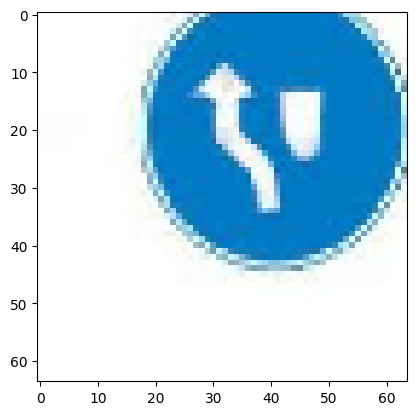

time: 199 ms (started: 2025-10-28 11:05:56 +00:00)


In [ ]:
plt.imshow(X[105])

In [ ]:
train['tags'][105]

"['የአደባባዩን_ግራ_ይዘህ_ንዳ']"

In [ ]:
y = np.array(train.drop(['image', 'tags'],axis=1))
y.shape

(11000, 156)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=5, test_size=0.2)

In [ ]:
# Size of train and test datasets
print('X_train size:', X_train.shape)
print('y_train size:', y_train.shape)
print('X_test size:', X_test.shape)
print('y_test size:', y_test.shape)

X_train size: (8800, 64, 64, 3)
y_train size: (8800, 156)
X_test size: (2200, 64, 64, 3)
y_test size: (2200, 156)


# **Mobile Net Base model**

In [ ]:
from keras import models
from keras import layers

#Load the MobileNet model
IMAGE_SIZE=[64,64]
Mobilenet = MobileNet(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

# Freeze nothing layers
for layer in Mobilenet.layers:
  layer.trainable = False

# Create the model
with tf.device('/gpu:0'):
  base_mobilenet = tf.keras.models.Sequential()
  base_mobilenet.add(Mobilenet)
  # Add new layers
  # base_mobilenet.add(layers.Flatten())
  # base_mobilenet.add(layers.Dense(1024, activation='relu'))
  # base_mobilenet.add(layers.Dense(156, activation='softmax'))

  base_mobilenet.add(layers.GlobalAveragePooling2D())
  base_mobilenet.add(layers.Reshape((1, 1, 1024)))
  base_mobilenet.add(layers.Dropout(0.001))
  base_mobilenet.add(layers.Conv2D(156, (1, 1), padding='same'))
  base_mobilenet.add(layers.Activation(activation='softmax'))
  base_mobilenet.add(layers.Reshape((156,)))
  base_mobilenet.summary()

/tmp/ipykernel_1018/1935842014.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  Mobilenet = MobileNet(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_1.00_224 (Functional) │ (None, 2, 2, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1, 1, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 1, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 1, 1, 156)      │       159,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1, 1, 156)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 156)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,388,764 (12.93 MB)

 Trainable params: 159,900 (624.61 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

# **Train the model**

In [ ]:
import time # Import the time module
# tf.data.experimental.enable_debug_mode()
lr = 0.0001
epoch = 150
#t0 = time.time()
with tf.device('/gpu:0'):
  opt = tf.keras.optimizers.Adamax(learning_rate=lr, decay = 1e-6)
  base_mobilenet.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
  early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',      # Metric to monitor
    mode='max',
    patience=5,             # Wait 10 epochs without improvement
    verbose=1,
    restore_best_weights=True)
  MN = base_mobilenet.fit(X_train, y_train, epochs=epoch, validation_split = 0.1, batch_size=32, callbacks=[early_stop])
# print("Training time:", time.time()-t0)

Epoch 1/150
248/248 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.0116 - loss: 5.4530 - val_accuracy: 0.0341 - val_loss: 4.8752
Epoch 2/150
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.0480 - loss: 4.5606 - val_accuracy: 0.0614 - val_loss: 4.2510
Epoch 3/150
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0926 - loss: 4.0239 - val_accuracy: 0.1114 - val_loss: 3.8116
Epoch 4/150
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1535 - loss: 3.6193 - val_accuracy: 0.1784 - val_loss: 3.4670
Epoch 5/150
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2210 - loss: 3.2934 - val_accuracy: 0.2386 - val_loss: 3.1885
Epoch 6/150
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2816 - loss: 3.0261 - val_accuracy: 0.3000 - val_loss: 2.9538
Epoch 7/150
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3408 - loss: 2.7984 - val_accuracy: 0.3500 - val_loss: 2.7546
Epoch 8/150
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3914 - loss: 2.6071 - val_ac

In [ ]:
# Save models
# !mkdir -p saved_model
mobilenet.save('traffic_finetuned_mobilenet.keras')

In [ ]:
#load the model
from keras.models import load_model
import tensorflow as tf

with tf.device('/gpu:0'):
  bn = load_model('BN.h5')

In [ ]:
# Find train and test accuracy
with tf.device('/gpu:0'):
  loss, accuracy = base_mobilenet.evaluate(X_train, y_train, verbose=False)
  print("Training Accuracy: {:.2f}".format(accuracy *100))
  print("Training loss: {:.2f}".format(loss *100))
  loss, accuracy = base_mobilenet.evaluate(X_test, y_test, verbose=False)
  print("Testing Accuracy:  {:.2f}".format(accuracy *100))
  print("Testing loss:  {:.2f}".format(loss *100))
  # print("Training time:", time.time()-t0)

Training Accuracy: 93.84
Training loss: 43.78
Testing Accuracy:  85.41
Testing loss:  61.39



**Mobile Net graph**
---



In [ ]:
# plot the training loss and accuracy
plt.style.use("ggplot")
plt.figure()
N = 100
plt.rcParams['font.size'] = '12'
plt.rcParams['font.weight'] = 'bold'


plt.plot(BMN.history["accuracy"], 'b', label="base MobileNet-train acc")
plt.plot(BMN.history["val_accuracy"], 'g', label="base MobileNet-test acc")


plt.plot(MN.history["accuracy"], 'skyblue', label="tuned MobileNet-train acc")
plt.plot(MN.history["val_accuracy"], 'purple', label="tuned MobileNet-test acc")


plt.xlabel('font', weight='bold')
plt.ylabel('font', weight='bold')
plt.title('font', weight='bold')
plt.title("Training & Testing Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Accuracy")
plt.legend(loc="lower right")
plt.ylim(0.5,1)
plt.savefig('accuracy.png')

In [ ]:
# plot the training loss and accuracy
plt.style.use("ggplot")
plt.figure()
N = 100
plt.rcParams['font.size'] = '12'
plt.rcParams['font.weight'] = 'bold'


plt.plot(BMN.history["loss"], 'yellow',label="base Mobile Net-train loss")
plt.plot(BMN.history["val_loss"], 'r', label="base MobileNet-test loss")

plt.plot(MN.history["loss"], 'brown', label="tuned MobileNet-train loss")
plt.plot(MN.history["val_loss"], 'orange', label="tuned MobileNet-test loss")

plt.xlabel('font', weight='bold')
plt.ylabel('font', weight='bold')
plt.title('font', weight='bold')
plt.title("Training & Testing Loss")
plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.legend(loc="upper right")
plt.ylim(2.5,0.0)
plt.savefig('loss.png')

In [ ]:
#load the model
from keras.models import load_model
import tensorflow as tf

with tf.device('/gpu:0'):
  NBN = load_model('NBN.h5')
  bn = load_model('BN.h5')

In [ ]:
from keras.models import load_model
mobilenet = load_model("mobilemulticlass.h5")

In [ ]:
from keras.preprocessing import image
from tensorflow.keras.utils import img_to_array
img = tf.keras.utils.load_img('/content/drive/My Drive/traffic/bicycle_allowed_only.jpg', target_size=(64,64,3))
img = img_to_array(img)
img = img/255

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
ለብስክሌት_ብቻ_የተፈቀደ_ነው =  1e+02 % 


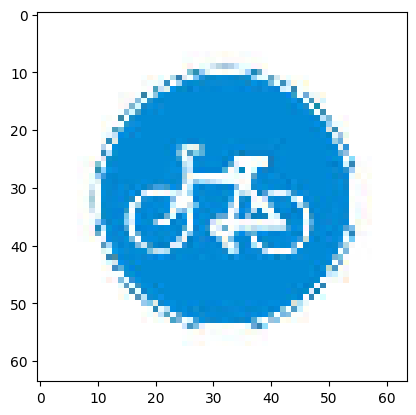

In [ ]:
classes = np.array(train.columns[2:])
with tf.device('/gpu:0'):
  proba = mobilenet.predict(img.reshape(1,64,64,3))
  top_3 = np.argsort(proba[0])[:-6:-1]
  for i in range(1):
       print("{} = ".format(classes[top_3[i]])+" {:.3} % ".format(proba[0][top_3[i]] *100))
plt.grid(False)
plt.imshow(img)



# **Confusion Matrix**

In [ ]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
# from sklearn.utils.multi_label import unique_labels
from sklearn.utils.multiclass import unique_labels
plt.rcParams['font.size'] = '13'
# Get predicted values
y_pred = base_mobilenet.predict(X_test)  # outputs probabilities of each classes
# Create empty numpy array to match length of training data
y_pred_array = np.zeros(X_test.shape[0])
plt.rcParams['font.size'] = '13'
# Find class with highest probability
for i in range(0, y_pred.shape[0]):
    label_predict = np.argmax(y_pred[i]) # column with max probability
    y_pred_array[i] = label_predict

# convert to integers
y_pred_array = y_pred_array.astype(int)

# Convert y_test to 1d numpy array
y_test_array = np.zeros(X_test.shape[0])

# Find class with 1
for i in range(0, y_test.shape[0]):
    label_predict = np.argmax(y_test[i])
    y_test_array[i] = label_predict

y_test_array = y_test_array.astype(int)
# class_names = np.array(['ለብስክሌት_ብቻ_የተፈቀደ_ነው',	'የአደባባዩን_ግራ_ይዘህ_ንዳ',	'የአደባባዩን_ቀኝ_ይዘህ_ንዳ',	'በመንገዱ_ላይ_የተፈቀደ_አነስተኛ_ፍጥነት_መጨረሻ',
#                         'ፍንዳታ_ለሚያስከትል_ጭነት_የተፈቀደ',	'በግራ_በኩል_ያሽከርክሩ',	'በቀኝ_በኩል_ያሽከርክሩ',	'የጭነት_ተሽከርካሪ_መተላለፊያ',	'አደባባይ_መኖሩን_የሚገልጽ',
#                         'የተፈቀደ_አነስተኛ_የፍጥነት_መጠን',	'የመኪና_ማቆሚያን_የሚገልጽ',	'በቀስት_በተጠቆመው_አቅጣጫ_ቀጥል',
#                         'ወደ_ግራ_ታጠፍ',	'ተሸከርካሪዎች_ወደ_ተመሳሳይ_መዳረሻ_ለመጓዝ_በሁለቱም_በኩል_ሊያልፉ_ይችላሉ',
#                         'ለአንድ_መስመር_ከተቀመጠው_አነስተኛ_ፍጥነት_በላይ_ማሽከርከርን_የሚያስገድድ',
#                         'በተለያየ_መስመር_ውስጥ_ተፈጻሚ_እንድሆን_የተቀመጠ_አነስተኛ_የፍጥነት_ወሰን',	'በተለያየ_መስመር_ውስጥ_ተፈጻሚ_እንድሆን_የተቀመ_የፍጥነት_ወሰን',
#                         'አልጋ_መኖሩን_የሚገልጽ',	'የእግረኛ_መንገድ',	'አንድ_ማይል_ርቀት_ወደ_ፓርኪንግ_ቦታ',	'የመመገቢያ_ቦታ',	'መሙያ_ጣቢያ',	'የመጀመሪያ_እርዳታን_የሚገልጽ',
#                         'ሆስፒታል',	'መረጃ_ቤት',	'መዝናኛ_ወይም_ቡና_ቤት_መኖሩን_የሚገልጽ',	'የመኪና_ማቆሚያ_ቦታ_ከድንገተኛ_ስልክ_ጋር',	'የመኪና_ማቆሚያ_ቦታ',
#                         'የጥገና_ቦታ',	'በዚህ_ለተሽከርካሪ_ትራፊክ_መንገድ_የለም',	'ለተሽከርካ_ትራፊክ_መንገድ_የለም',	'የአንድ_መንገድ_ትራፊክ',
#                         'የህዝብ_ቴሌፎን',	'የጥገና_ፋሲሊቲ',	'የክፍያ_ዳስ_ምልክት',	'የቱሪስት_እረፍት_ወይም_አካባቢ',	'የጭነት_መኝታ_ምልክት',	'መንቃት_እዚህ_ይጀመራል',
#                         'የክብደት_ገደብ',	'ደንበኞች',	'የቅድሚያ_መንገዱ_መጨረሻ',	'የመጨረሻ_ከተማ_ፍጥነት_ገደብ',	'ባዶ_መንገድ_ስጥ',	'ለሚመጡ_ተሽከርካሪዎች_መንገድ_ስጥ',
#                         'መንገድ_ስጥ',	'በእንስሳት_የሚነዱ_ጋሪዎች_የሉም',	'ምንም_ሳይክል_የለም',	'መግቢያ_የለም',	'ፈንጂዎች_የሉም',	'ከተጠቆመው_ክብደት_በላይ_ምንም_ዕቃ_የለም',
#                         'በእጅ_የሚነዳ_ጋሪ_የለም',	'ጥሩምባ_የለም','ወደ_ግራ_መታጠፍ_የተከለከለ',	'ለተጫነ_ተሽከርካሪ_ማለፍ_የለም',	'ምንም_ተሽከርካሪ_ከሶሎ_ሞተር_ሳይክል_በስተቀር',	'ምንም_ሞተር_ተሽከርካሪ',
#                         'ከሁለት_እግር_በላይ_ያላቸው_ተሽከርካሪዎች_መቅደም_የተከለከለ',	'የመኪና_ማቆሚያ_የለም',	'እግረኞች_የሉም',	'ወደ_ቀኝ_መታጠፍ_የተከለከለ',	'ብቸኛ_ሞተር_ሳይክል_የለም',
#                         'ማቆም_የለም',	'የሚጎተት_መኪና_የለም',	'የተጎተቱ_ካራቫስ_የለም',	'የከተማ_ክልል',	'ወደ_U_ግራ_መታጠፍ_የለም',	'ወደ_U_ቀኝ_መታጠፍ_የለም',
#                         'ምንም_የተሽከርካሪ_እጀታ_ጭነት_በላይ_አልተገለጸም',	'ከ20_ቶን_በላይ_ተሽከርካሪ_የተከለከለ',	'ተሽከርካሪ_የለም',	'ከከፍተኛው_ወርድ_በላይ_ምንም_ተሽከርካሪ_አይታይም',
#                         'ከተገለጸው_ርዝመት_በላይ_የተከለከለ',	'ከሚታየው_ከፍታ_በላይ_ምንም_ተሽከርካሪ_ማለፍ_አይችልም',	'የመጠበቅ_መጨረሻ',	'አይጠበቅም',	'ቅድሚያ_መንገድ',	'ገደብ_አልቋል',
#                         'መስቀለኛ_መንገድ_ከመግባትህ_በፊት_አቁም',	'አቁም',	'ከፍተኛው_ፍጥነት',	'መኪና_አለ',	'ወደግራ_ታጠፍ',	'ወደ_ቀኝ_ታጠፍ',	'ጋሪዎች_ከፊት_አሉ',
#                         'የቁልቁል_ማርከሮች',	'መስቀለኛ_መንገድ',	'የአካል_ጉዳተኛ_ሰው',	'ድርብ_ታጠፍ',	'ድርብ_ቁልቁል_ማርከሮች',	'በጥንቃቄ_መንዳት',	'የአስፋልት_መንገድ_መጨረሻ',
#                         'የድልድይ_ግድግዳ_መጨረሻ',	'የሁለት_ጋሪ_መንገድ_መጨረሻ',	'በሁለት_የተከፈለ_መንገድ_መጨረሻ',	'የእርሻ_ማሽን_የሚገልጽ_1',	'የእርሻ_ማሽን_የሚገልጽ_2',
#                         'ከፊት_ቀያሽ_አለ',	'መጀመሪያ_ግራ_ከዚያ_ቀጥታ_ታጠፍ',	'መጀመሪያ_ቀኝ_ከዚያ_ቀጥታ_ታጠፍ',	'ከውሃ_እስከ_አስፋልት_መንገድ',	'ለባቡር_ሎኮሞቲቭ_መንገድ_ስጥ',
#                         'ጎባጣ_ድልድይ',	'የቤት_እንስሳት',	'ከታጣፊ_መንገድ_ላይ_የሚገነጠል',	'የሚጫወቱ_ልጆች',	'ደረጃ_በእንቅፋት_መሻገር',	'የተጫነ_ደረቅ_ተሽከርካሪ_ከፊት',	'ወንዶች_በስራ_ ላይ',
#                         'ጠባብ_ድልድይ',	'በመንገዳው_በሁለት_መንገድ_ተከፈለ',	'ከፍት_ወይም_ዳገታማ_ድልድይ_ከፊት',	'ማረሻ_የእርሻ_ተሽከርካሪ_ከፊት',	'ወንዝ_ዳር',
#                         'ተከታታይ_መኪና',	'ድርብ_የባቡር_መስመር',	'ባቡር_በስተግራ_ይሻገራል',	'ባቡር_በስተቀኝ_ይሻገራል',	'ነጠላ_የባቡር_አቋራጭ',	'በመንገዱ_አቋራጭ_የባቡር_ሎኮሞቲቭ',	'የባቡር_መሻገሪያ_T',
#                         'የመውደቅ_ወይም_የመውደቅ_ስጋት_መንገድ',	'የመንገድ_ጉብታዎች',	'በሁለቱም_ጎን_መንገዱ_ይጠባል',	'መንገዱ_በቀኝ_ይጠባል',	'መንገድ_ከኪሳራ_ጋር',	'የመንገድ_ስራ_ከፊት',
#                         'ክብ_ዙር',	'ትምህርት_ቤት',	'የመንገዱን_ወደ_ግራ_ጥርት_ማዘዋወር',	'የመንገዱን_አቅጣጫ_አጥራ',	'የጎን_መንገድ_ቅርንጫፍ_ግራ',	'የጎን_መንገድ_ቅርንጫፍ_ቀኝ',	'የግራ_ጎን_መንገድ',
#                         'ሰያፍ_የቀኝ_ጎን_መንገድ',	'የጎን_መንገድ_ቀኝ',	'ተንሸራታች_መንገድ',	'ሁለት_መንታ_ያለው_መንገድ',	'ቁልቁል_ዳገት_ወደታች',	'ቁልቁል_ዳገት_ወደላይ',	'አመላካች',	'T_ቅርጽ_ያለው_መንገድ',
#                         'T_ቅርጽ',	'በግራ_በኩል_የሚዋሃድ_መንገድ_አለ',	'ከፊት_የትራፊክ_ምልክቶች_አሉ',	'ትራም_በመንገድ_ላይ',	'የሁለት_መንገድ_ትራፊክ_በፊት_ማቋረጫ_ላይ',
#                         'ባለሁለት_መንገድ_ትራፊክ',	'ያልተስተካከለ_መንገድ',	'የማስጠንቀቂያ_ቀስት_እና_መሰጠት_ውስጥ',	'የማስጠንቀቂያ_ቀስት_ወደፊት_ይቆማል',	'የውሃ_ኮርስ_በመንገድ_ዳር',
#                         'የዱር_እንስሳት',	'ነፋስ',	'y_መገናኛ',	'የዜብራ_መንገድ',	'ዝግዛግ_መንገድ'])

# def plot_confusion_matrix(y_true, y_pred, classes,
#                           normalize=False,
#                           title=None,
#                           cmap=plt.cm.Blues):
#   # This function prints and plots the confusion matrix. Normalization can be applied by setting `normalize=True`."""
#   if not title:
#     if normalize:
#       title = 'Normalized confusion matrix'
#     else:
#       title = 'Confusion matrix'


#   # Compute confusion matrix
#   cm = confusion_matrix(y_true, y_pred)
#   # Only use the labels that appear in the data
#   classes = classes[unique_labels(y_true, y_pred)]
#   if normalize:
#     cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]*100
#     print("Normalized confusion matrix")
#   else:
#     print('Confusion matrix')
#   print(cm)
#   fig, ax = plt.subplots(figsize=(8,8))
#   im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
#   ax.figure.colorbar(im, ax=ax)
#   # We want to show all ticks
#   ax.set(xticks=np.arange(cm.shape[1]),
#          yticks=np.arange(cm.shape[0]),
#          # ... and label them with the respective list entries
#          xticklabels=classes, yticklabels=classes,
#          title=title,
#          ylabel='True label',
#          xlabel='Predicted label')
#   # Rotate the tick labels and set their alignment.
#   #plt.setp('font', weight='bold')
#   plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
#   # Loop over data dimensions and create text annotations.
#   fmt = '.2f' if normalize else 'd'
#   thresh = cm.max() / 2.
#   for i in range(cm.shape[0]):
#     for j in range(cm.shape[1]):
#       ax.text(j, i, format(cm[i, j], fmt),
#               ha="center", va="center",
#               color="white" if cm[i, j] > thresh else "black")
#   fig.tight_layout()
#   return ax
# np.set_printoptions(precision=2)
# plt.figure(figsize=(170,170))
# # Plot non-normalized confusion matrix
# plot_confusion_matrix(y_test_array, y_pred_array, classes=class_names,
#                       title='Confusion matrix')
# plt.grid(False)

# # Plot normalized confusion matrix
# plot_confusion_matrix(y_test_array, y_pred_array, classes=class_names, normalize=True,
#                       title='Normalized confusion matrix')
# plt.grid(False)

# plt.show()



69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step


# **Classification report**

In [ ]:
#classification report
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.metrics import classification_report
# print(confusion_matrix(y_test_array, y_pred_array))
target_names = ['ለብስክሌት_ብቻ_የተፈቀደ_ነው',	'የአደባባዩን_ግራ_ይዘህ_ንዳ',	'የአደባባዩን_ቀኝ_ይዘህ_ንዳ',	'በመንገዱ_ላይ_የተፈቀደ_አነስተኛ_ፍጥነት_መጨረሻ',
                        'ፍንዳታ_ለሚያስከትል_ጭነት_የተፈቀደ',	'በግራ_በኩል_ያሽከርክሩ',	'በቀኝ_በኩል_ያሽከርክሩ',	'የጭነት_ተሽከርካሪ_መተላለፊያ',	'አደባባይ_መኖሩን_የሚገልጽ',
                        'የተፈቀደ_አነስተኛ_የፍጥነት_መጠን',	'የመኪና_ማቆሚያን_የሚገልጽ',	'በቀስት_በተጠቆመው_አቅጣጫ_ቀጥል',
                        'ወደ_ግራ_ታጠፍ',	'ተሸከርካሪዎች_ወደ_ተመሳሳይ_መዳረሻ_ለመጓዝ_በሁለቱም_በኩል_ሊያልፉ_ይችላሉ',
                        'ለአንድ_መስመር_ከተቀመጠው_አነስተኛ_ፍጥነት_በላይ_ማሽከርከርን_የሚያስገድድ',
                        'በተለያየ_መስመር_ውስጥ_ተፈጻሚ_እንድሆን_የተቀመጠ_አነስተኛ_የፍጥነት_ወሰን',	'በተለያየ_መስመር_ውስጥ_ተፈጻሚ_እንድሆን_የተቀመ_የፍጥነት_ወሰን',
                        'አልጋ_መኖሩን_የሚገልጽ',	'የእግረኛ_መንገድ',	'አንድ_ማይል_ርቀት_ወደ_ፓርኪንግ_ቦታ',	'የመመገቢያ_ቦታ',	'መሙያ_ጣቢያ',	'የመጀመሪያ_እርዳታን_የሚገልጽ',
                        'ሆስፒታል',	'መረጃ_ቤት',	'መዝናኛ_ወይም_ቡና_ቤት_መኖሩን_የሚገልጽ',	'የመኪና_ማቆሚያ_ቦታ_ከድንገተኛ_ስልክ_ጋር',	'የመኪና_ማቆሚያ_ቦታ',
                        'የጥገና_ቦታ',	'በዚህ_ለተሽከርካሪ_ትራፊክ_መንገድ_የለም',	'ለተሽከርካ_ትራፊክ_መንገድ_የለም',	'የአንድ_መንገድ_ትራፊክ',
                        'የህዝብ_ቴሌፎን',	'የጥገና_ፋሲሊቲ',	'የክፍያ_ዳስ_ምልክት',	'የቱሪስት_እረፍት_ወይም_አካባቢ',	'የጭነት_መኝታ_ምልክት',	'መንቃት_እዚህ_ይጀመራል',
                        'የክብደት_ገደብ',	'ደንበኞች',	'የቅድሚያ_መንገዱ_መጨረሻ',	'የመጨረሻ_ከተማ_ፍጥነት_ገደብ',	'ባዶ_መንገድ_ስጥ',	'ለሚመጡ_ተሽከርካሪዎች_መንገድ_ስጥ',
                        'መንገድ_ስጥ',	'በእንስሳት_የሚነዱ_ጋሪዎች_የሉም',	'ምንም_ሳይክል_የለም',	'መግቢያ_የለም',	'ፈንጂዎች_የሉም',	'ከተጠቆመው_ክብደት_በላይ_ምንም_ዕቃ_የለም',
                        'በእጅ_የሚነዳ_ጋሪ_የለም',	'ጥሩምባ_የለም','ወደ_ግራ_መታጠፍ_የተከለከለ',	'ለተጫነ_ተሽከርካሪ_ማለፍ_የለም',	'ምንም_ተሽከርካሪ_ከሶሎ_ሞተር_ሳይክል_በስተቀር',	'ምንም_ሞተር_ተሽከርካሪ',
                        'ከሁለት_እግር_በላይ_ያላቸው_ተሽከርካሪዎች_መቅደም_የተከለከለ',	'የመኪና_ማቆሚያ_የለም',	'እግረኞች_የሉም',	'ወደ_ቀኝ_መታጠፍ_የተከለከለ',	'ብቸኛ_ሞተር_ሳይክል_የለም',
                        'ማቆም_የለም',	'የሚጎተት_መኪና_የለም',	'የተጎተቱ_ካራቫስ_የለም',	'የከተማ_ክልል',	'ወደ_U_ግራ_መታጠፍ_የለም',	'ወደ_U_ቀኝ_መታጠፍ_የለም',
                        'ምንም_የተሽከርካሪ_እጀታ_ጭነት_በላይ_አልተገለጸም',	'ከ20_ቶን_በላይ_ተሽከርካሪ_የተከለከለ',	'ተሽከርካሪ_የለም',	'ከከፍተኛው_ወርድ_በላይ_ምንም_ተሽከርካሪ_አይታይም',
                        'ከተገለጸው_ርዝመት_በላይ_የተከለከለ',	'ከሚታየው_ከፍታ_በላይ_ምንም_ተሽከርካሪ_ማለፍ_አይችልም',	'የመጠበቅ_መጨረሻ',	'አይጠበቅም',	'ቅድሚያ_መንገድ',	'ገደብ_አልቋል',
                        'መስቀለኛ_መንገድ_ከመግባትህ_በፊት_አቁም',	'አቁም',	'ከፍተኛው_ፍጥነት',	'መኪና_አለ',	'ወደግራ_ታጠፍ',	'ወደ_ቀኝ_ታጠፍ',	'ጋሪዎች_ከፊት_አሉ',
                        'የቁልቁል_ማርከሮች',	'መስቀለኛ_መንገድ',	'የአካል_ጉዳተኛ_ሰው',	'ድርብ_ታጠፍ',	'ድርብ_ቁልቁል_ማርከሮች',	'በጥንቃቄ_መንዳት',	'የአስፋልት_መንገድ_መጨረሻ',
                        'የድልድይ_ግድግዳ_መጨረሻ',	'የሁለት_ጋሪ_መንገድ_መጨረሻ',	'በሁለት_የተከፈለ_መንገድ_መጨረሻ',	'የእርሻ_ማሽን_የሚገልጽ_1',	'የእርሻ_ማሽን_የሚገልጽ_2',
                        'ከፊት_ቀያሽ_አለ',	'መጀመሪያ_ግራ_ከዚያ_ቀጥታ_ታጠፍ',	'መጀመሪያ_ቀኝ_ከዚያ_ቀጥታ_ታጠፍ',	'ከውሃ_እስከ_አስፋልት_መንገድ',	'ለባቡር_ሎኮሞቲቭ_መንገድ_ስጥ',
                        'ጎባጣ_ድልድይ',	'የቤት_እንስሳት',	'ከታጣፊ_መንገድ_ላይ_የሚገነጠል',	'የሚጫወቱ_ልጆች',	'ደረጃ_በእንቅፋት_መሻገር',	'የተጫነ_ደረቅ_ተሽከርካሪ_ከፊት',	'ወንዶች_በስራ_ ላይ',
                        'ጠባብ_ድልድይ',	'በመንገዳው_በሁለት_መንገድ_ተከፈለ',	'ከፍት_ወይም_ዳገታማ_ድልድይ_ከፊት',	'ማረሻ_የእርሻ_ተሽከርካሪ_ከፊት',	'ወንዝ_ዳር',
                        'ተከታታይ_መኪና',	'ድርብ_የባቡር_መስመር',	'ባቡር_በስተግራ_ይሻገራል',	'ባቡር_በስተቀኝ_ይሻገራል',	'ነጠላ_የባቡር_አቋራጭ',	'በመንገዱ_አቋራጭ_የባቡር_ሎኮሞቲቭ',	'የባቡር_መሻገሪያ_T',
                        'የመውደቅ_ወይም_የመውደቅ_ስጋት_መንገድ',	'የመንገድ_ጉብታዎች',	'በሁለቱም_ጎን_መንገዱ_ይጠባል',	'መንገዱ_በቀኝ_ይጠባል',	'መንገድ_ከኪሳራ_ጋር',	'የመንገድ_ስራ_ከፊት',
                        'ክብ_ዙር',	'ትምህርት_ቤት',	'የመንገዱን_ወደ_ግራ_ጥርት_ማዘዋወር',	'የመንገዱን_አቅጣጫ_አጥራ',	'የጎን_መንገድ_ቅርንጫፍ_ግራ',	'የጎን_መንገድ_ቅርንጫፍ_ቀኝ',	'የግራ_ጎን_መንገድ',
                        'ሰያፍ_የቀኝ_ጎን_መንገድ',	'የጎን_መንገድ_ቀኝ',	'ተንሸራታች_መንገድ',	'ሁለት_መንታ_ያለው_መንገድ',	'ቁልቁል_ዳገት_ወደታች',	'ቁልቁል_ዳገት_ወደላይ',	'አመላካች',	'T_ቅርጽ_ያለው_መንገድ',
                        'T_ቅርጽ',	'በግራ_በኩል_የሚዋሃድ_መንገድ_አለ',	'ከፊት_የትራፊክ_ምልክቶች_አሉ',	'ትራም_በመንገድ_ላይ',	'የሁለት_መንገድ_ትራፊክ_በፊት_ማቋረጫ_ላይ',
                        'ባለሁለት_መንገድ_ትራፊክ',	'ያልተስተካከለ_መንገድ',	'የማስጠንቀቂያ_ቀስት_እና_መሰጠት_ውስጥ',	'የማስጠንቀቂያ_ቀስት_ወደፊት_ይቆማል',	'የውሃ_ኮርስ_በመንገድ_ዳር',
                        'የዱር_እንስሳት',	'ነፋስ',	'y_መገናኛ',	'የዜብራ_መንገድ',	'ዝግዛግ_መንገድ']
# print(classification_report(y_test_array, y_pred_array, labels=[0,1,2,3]))
print(classification_report(y_test_array, y_pred_array, target_names=target_names))

                                                 precision    recall  f1-score   support

                             ለብስክሌት_ብቻ_የተፈቀደ_ነው       1.00      1.00      1.00        10
                              የአደባባዩን_ግራ_ይዘህ_ንዳ       1.00      1.00      1.00        13
                              የአደባባዩን_ቀኝ_ይዘህ_ንዳ       1.00      1.00      1.00        14
                 በመንገዱ_ላይ_የተፈቀደ_አነስተኛ_ፍጥነት_መጨረሻ       1.00      1.00      1.00        13
                         ፍንዳታ_ለሚያስከትል_ጭነት_የተፈቀደ       1.00      1.00      1.00        10
                                 በግራ_በኩል_ያሽከርክሩ       1.00      1.00      1.00        22
                                 በቀኝ_በኩል_ያሽከርክሩ       1.00      1.00      1.00        12
                             የጭነት_ተሽከርካሪ_መተላለፊያ       1.00      1.00      1.00        16
                               አደባባይ_መኖሩን_የሚገልጽ       1.00      1.00      1.00        13
                          የተፈቀደ_አነስተኛ_የፍጥነት_መጠን       1.00      1.00      1.00        16
                    

# **MobileNet** **Metrics** **Matrix**

In [ ]:
import numpy as np
y_gt = y_test_array
y_pr = y_pred_array
from sklearn.metrics import f1_score, precision_score,recall_score
p_macro = precision_score(y_gt, y_pr, average="macro")
p_micro = precision_score(y_gt, y_pr, average="micro")
p_weighted = precision_score(y_gt, y_pr, average="weighted")
r_macro = recall_score(y_gt, y_pr, average="macro")
r_micro = recall_score(y_gt, y_pr, average="micro")
r_weighted = recall_score(y_gt, y_pr, average="weighted")
fl_macro = f1_score(y_gt, y_pr, average="macro")
f1_micro = f1_score(y_gt, y_pr, average="micro")
f1_weighted = f1_score(y_gt, y_pr, average="weighted")
print('============ Precision Score ============')
print("P_macro:  {:.2f}".format(p_macro *100))
print("P_micro:  {:.2f}".format(p_micro *100))
print("P_weighted:  {:.2f}".format(p_weighted *100))
print('============ Recall Score ============')
print("R_macro:  {:.2f}".format(r_macro *100))
print("R_micro:  {:.2f}".format(r_micro *100))
print("R_weighted:  {:.2f}".format(r_weighted *100))
print('============ F1 Score ============')
print("F1_macro:  {:.2f}".format(fl_macro *100))
print("F1_micro:  {:.2f}".format(f1_micro*100))
print("F1_weighted:  {:.2f}".format(f1_weighted*100))

============ Precision Score ============
P_macro:  79.17
P_micro:  81.23
P_weighted:  82.42
============ Recall Score ============
R_macro:  79.71
R_micro:  81.23
R_weighted:  81.23
============ F1 Score ============
F1_macro:  78.58
F1_micro:  81.23
F1_weighted:  81.11


# **Mobile Net Metrix**

In [ ]:
from sklearn.metrics import average_precision_score
average_precision_score(y_test, y_pred, average='micro')


In [ ]:
import numpy as np
from sklearn.metrics import coverage_error
from sklearn.metrics import label_ranking_average_precision_score
from sklearn.metrics import label_ranking_loss
from sklearn.metrics import explained_variance_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_log_error
from sklearn.metrics import r2_score
from sklearn.metrics import hamming_loss, accuracy_score
# coverage error
y_score = mobilenet.predict(X_test)
# y_pred = (y_score>0.5)
ce = coverage_error(y_test, y_score)
# label ranking average precision score
lraps = label_ranking_average_precision_score(y_test, y_score)
# label ranking loss
lrl = label_ranking_loss(y_test, y_score)
# explained variance score
evs = explained_variance_score(y_test, y_score, multioutput='raw_values')
#  mean absolut error
mae = mean_absolute_error(y_test, y_score, multioutput='raw_values')
#  mean squered error
mse = mean_squared_error(y_test, y_score)
# mean squered logarithmic error
msle = mean_squared_log_error(y_test, y_score)
# R² score, the coefficient of determination¶
r2_score = r2_score(y_test, y_score, multioutput='raw_values')
#print('testing: ',y_score)
print('coverage error: ',ce)
print('label ranking average precision score: ',lraps)
print('label ranking loss: ',lrl)
print('explained variance score: ',evs)
print('mean absolute error: ',mae)
print('mean absolute logarithmic error: ',msle)
print('R2 score: ',r2_score)


In [ ]:
#load the model
from keras.models import load_model
import tensorflow as tf
tf.compat.v1.disable_eager_execution()
#tf.config.experimental_run_functions_eagerly(True)
with tf.device('/gpu:0'):
  mobilenet = load_model('potato_disease.h5')

Instructions for updating:
Colocations handled automatically by placer.


In [ ]:
class_names = np.array(['ለብስክሌት_ብቻ_የተፈቀደ_ነው',	'የአደባባዩን_ግራ_ይዘህ_ንዳ',	'የአደባባዩን_ቀኝ_ይዘህ_ንዳ',	'በመንገዱ_ላይ_የተፈቀደ_አነስተኛ_ፍጥነት_መጨረሻ',
                        'ፍንዳታ_ለሚያስከትል_ጭነት_የተፈቀደ',	'በግራ_በኩል_ያሽከርክሩ',	'በቀኝ_በኩል_ያሽከርክሩ',	'የጭነት_ተሽከርካሪ_መተላለፊያ',	'አደባባይ_መኖሩን_የሚገልጽ',
                        'የተፈቀደ_አነስተኛ_የፍጥነት_መጠን',	'የመኪና_ማቆሚያን_የሚገልጽ',	'በቀስት_በተጠቆመው_አቅጣጫ_ቀጥል',
                        'ወደ_ግራ_ታጠፍ',	'ተሸከርካሪዎች_ወደ_ተመሳሳይ_መዳረሻ_ለመጓዝ_በሁለቱም_በኩል_ሊያልፉ_ይችላሉ',
                        'ለአንድ_መስመር_ከተቀመጠው_አነስተኛ_ፍጥነት_በላይ_ማሽከርከርን_የሚያስገድድ',
                        'በተለያየ_መስመር_ውስጥ_ተፈጻሚ_እንድሆን_የተቀመጠ_አነስተኛ_የፍጥነት_ወሰን',	'በተለያየ_መስመር_ውስጥ_ተፈጻሚ_እንድሆን_የተቀመ_የፍጥነት_ወሰን',
                        'አልጋ_መኖሩን_የሚገልጽ',	'የእግረኛ_መንገድ',	'አንድ_ማይል_ርቀት_ወደ_ፓርኪንግ_ቦታ',	'የመመገቢያ_ቦታ',	'መሙያ_ጣቢያ',	'የመጀመሪያ_እርዳታን_የሚገልጽ',
                        'ሆስፒታል',	'መረጃ_ቤት',	'መዝናኛ_ወይም_ቡና_ቤት_መኖሩን_የሚገልጽ',	'የመኪና_ማቆሚያ_ቦታ_ከድንገተኛ_ስልክ_ጋር',	'የመኪና_ማቆሚያ_ቦታ',
                        'የጥገና_ቦታ',	'በዚህ_ለተሽከርካሪ_ትራፊክ_መንገድ_የለም',	'ለተሽከርካ_ትራፊክ_መንገድ_የለም',	'የአንድ_መንገድ_ትራፊክ',
                        'የህዝብ_ቴሌፎን',	'የጥገና_ፋሲሊቲ',	'የክፍያ_ዳስ_ምልክት',	'የቱሪስት_እረፍት_ወይም_አካባቢ',	'የጭነት_መኝታ_ምልክት',	'መንቃት_እዚህ_ይጀመራል',
                        'የክብደት_ገደብ',	'ደንበኞች',	'የቅድሚያ_መንገዱ_መጨረሻ',	'የመጨረሻ_ከተማ_ፍጥነት_ገደብ',	'ባዶ_መንገድ_ስጥ',	'ለሚመጡ_ተሽከርካሪዎች_መንገድ_ስጥ',
                        'መንገድ_ስጥ',	'በእንስሳት_የሚነዱ_ጋሪዎች_የሉም',	'ምንም_ሳይክል_የለም',	'መግቢያ_የለም',	'ፈንጂዎች_የሉም',	'ከተጠቆመው_ክብደት_በላይ_ምንም_ዕቃ_የለም',
                        'በእጅ_የሚነዳ_ጋሪ_የለም',	'ጥሩምባ_የለም','ወደ_ግራ_መታጠፍ_የተከለከለ',	'ለተጫነ_ተሽከርካሪ_ማለፍ_የለም',	'ምንም_ተሽከርካሪ_ከሶሎ_ሞተር_ሳይክል_በስተቀር',	'ምንም_ሞተር_ተሽከርካሪ',
                        'ከሁለት_እግር_በላይ_ያላቸው_ተሽከርካሪዎች_መቅደም_የተከለከለ',	'የመኪና_ማቆሚያ_የለም',	'እግረኞች_የሉም',	'ወደ_ቀኝ_መታጠፍ_የተከለከለ',	'ብቸኛ_ሞተር_ሳይክል_የለም',
                        'ማቆም_የለም',	'የሚጎተት_መኪና_የለም',	'የተጎተቱ_ካራቫስ_የለም',	'የከተማ_ክልል',	'ወደ_ዩ_ግራ_መታጠፍ_የለም',	'ወደ_ዩ_ቀኝ_መታጠፍ_የለም',
                        'ምንም_የተሽከርካሪ_እጀታ_ጭነት_በላይ_አልተገለጸም',	'ከኸያ_ቶን_በላይ_ተሽከርካሪ_የተከለከለ',	'ተሽከርካሪ_የለም',	'ከከፍተኛው_ወርድ_በላይ_ምንም_ተሽከርካሪ_አይታይም',
                        'ከተገለጸው_ርዝመት_በላይ_የተከለከለ',	'ከሚታየው_ከፍታ_በላይ_ምንም_ተሽከርካሪ_ማለፍ_አይችልም',	'የመጠበቅ_መጨረሻ',	'አይጠበቅም',	'ቅድሚያ_መንገድ',	'ገደብ_አልቋል',
                        'መስቀለኛ_መንገድ_ከመግባትህ_በፊት_አቁም',	'አቁም',	'ከፍተኛው_ፍጥነት',	'መኪና_አለ',	'ወደግራ_ታጠፍ',	'ወደ_ቀኝ_ታጠፍ',	'ጋሪዎች_ከፊት_አሉ',
                        'የቁልቁል_ማርከሮች',	'መስቀለኛ_መንገድ',	'የአካል_ጉዳተኛ_ሰው',	'ድርብ_ታጠፍ',	'ድርብ_ቁልቁል_ማርከሮች',	'በጥንቃቄ_መንዳት',	'የአስፋልት_መንገድ_መጨረሻ',
                        'የድልድይ_ግድግዳ_መጨረሻ',	'የሁለት_ጋሪ_መንገድ_መጨረሻ',	'በሁለት_የተከፈለ_መንገድ_መጨረሻ',	'የእርሻ_ማሽን_የሚገልጽ_አንድ',	'የእርሻ_ማሽን_የሚገልጽ_ሁለት',
                        'ከፊት_ቀያሽ_አለ',	'መጀመሪያ_ግራ_ከዚያ_ቀጥታ_ታጠፍ',	'መጀመሪያ_ቀኝ_ከዚያ_ቀጥታ_ታጠፍ',	'ከውሃ_እስከ_አስፋልት_መንገድ',	'ለባቡር_ሎኮሞቲቭ_መንገድ_ስጥ',
                        'ጎባጣ_ድልድይ',	'የቤት_እንስሳት',	'ከታጣፊ_መንገድ_ላይ_የሚገነጠል',	'የሚጫወቱ_ልጆች',	'ደረጃ_በእንቅፋት_መሻገር',	'የተጫነ_ደረቅ_ተሽከርካሪ_ከፊት',	'ወንዶች_በስራ_ ላይ',
                        'ጠባብ_ድልድይ',	'በመንገዳው_በሁለት_መንገድ_ተከፈለ',	'ከፍት_ወይም_ዳገታማ_ድልድይ_ከፊት',	'ማረሻ_የእርሻ_ተሽከርካሪ_ከፊት',	'ወንዝ_ዳር',
                        'ተከታታይ_መኪና',	'ድርብ_የባቡር_መስመር',	'ባቡር_በስተግራ_ይሻገራል',	'ባቡር_በስተቀኝ_ይሻገራል',	'ነጠላ_የባቡር_አቋራጭ',	'በመንገዱ_አቋራጭ_የባቡር_ሎኮሞቲቭ',	'የባቡር_መሻገሪያ_T',
                        'የመውደቅ_ወይም_የመውደቅ_ስጋት_መንገድ',	'የመንገድ_ጉብታዎች',	'በሁለቱም_ጎን_መንገዱ_ይጠባል',	'መንገዱ_በቀኝ_ይጠባል',	'መንገድ_ከኪሳራ_ጋር',	'የመንገድ_ስራ_ከፊት',
                        'ክብ_ዙር',	'ትምህርት_ቤት',	'የመንገዱን_ወደ_ግራ_ጥርት_ማዘዋወር',	'የመንገዱን_አቅጣጫ_አጥራ',	'የጎን_መንገድ_ቅርንጫፍ_ግራ',	'የጎን_መንገድ_ቅርንጫፍ_ቀኝ',	'የግራ_ጎን_መንገድ',
                        'ሰያፍ_የቀኝ_ጎን_መንገድ',	'የጎን_መንገድ_ቀኝ',	'ተንሸራታች_መንገድ',	'ሁለት_መንታ_ያለው_መንገድ',	'ቁልቁል_ዳገት_ወደታች',	'ቁልቁል_ዳገት_ወደላይ',	'አመላካች',	'ቲ_ቅርጽ_ያለው_መንገድ',
                        'ቲ_ቅርጽ',	'በግራ_በኩል_የሚዋሃድ_መንገድ_አለ',	'ከፊት_የትራፊክ_ምልክቶች_አሉ',	'ትራም_በመንገድ_ላይ',	'የሁለት_መንገድ_ትራፊክ_በፊት_ማቋረጫ_ላይ',
                        'ባለሁለት_መንገድ_ትራፊክ',	'ያልተስተካከለ_መንገድ',	'የማስጠንቀቂያ_ቀስት_እና_መሰጠት_ውስጥ',	'የማስጠንቀቂያ_ቀስት_ወደፊት_ይቆማል',	'የውሃ_ኮርስ_በመንገድ_ዳር',
                        'የዱር_እንስሳት',	'ነፋስ',	'ዋይ_መገናኛ',	'የዜብራ_መንገድ',	'ዝግዛግ_መንገድ'])

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 4616 (\N{ETHIOPIC SYLLABLE LA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 4709 (\N{ETHIOPIC SYLLABLE BE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 4661 (\N{ETHIOPIC SYLLABLE SE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 4781 (\N{ETHIOPIC SYLLABLE KE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 4620 (\N{ETHIOPIC SYLLABLE LEE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 4725 (\N{ETHIOPIC SYLLABLE TE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/us

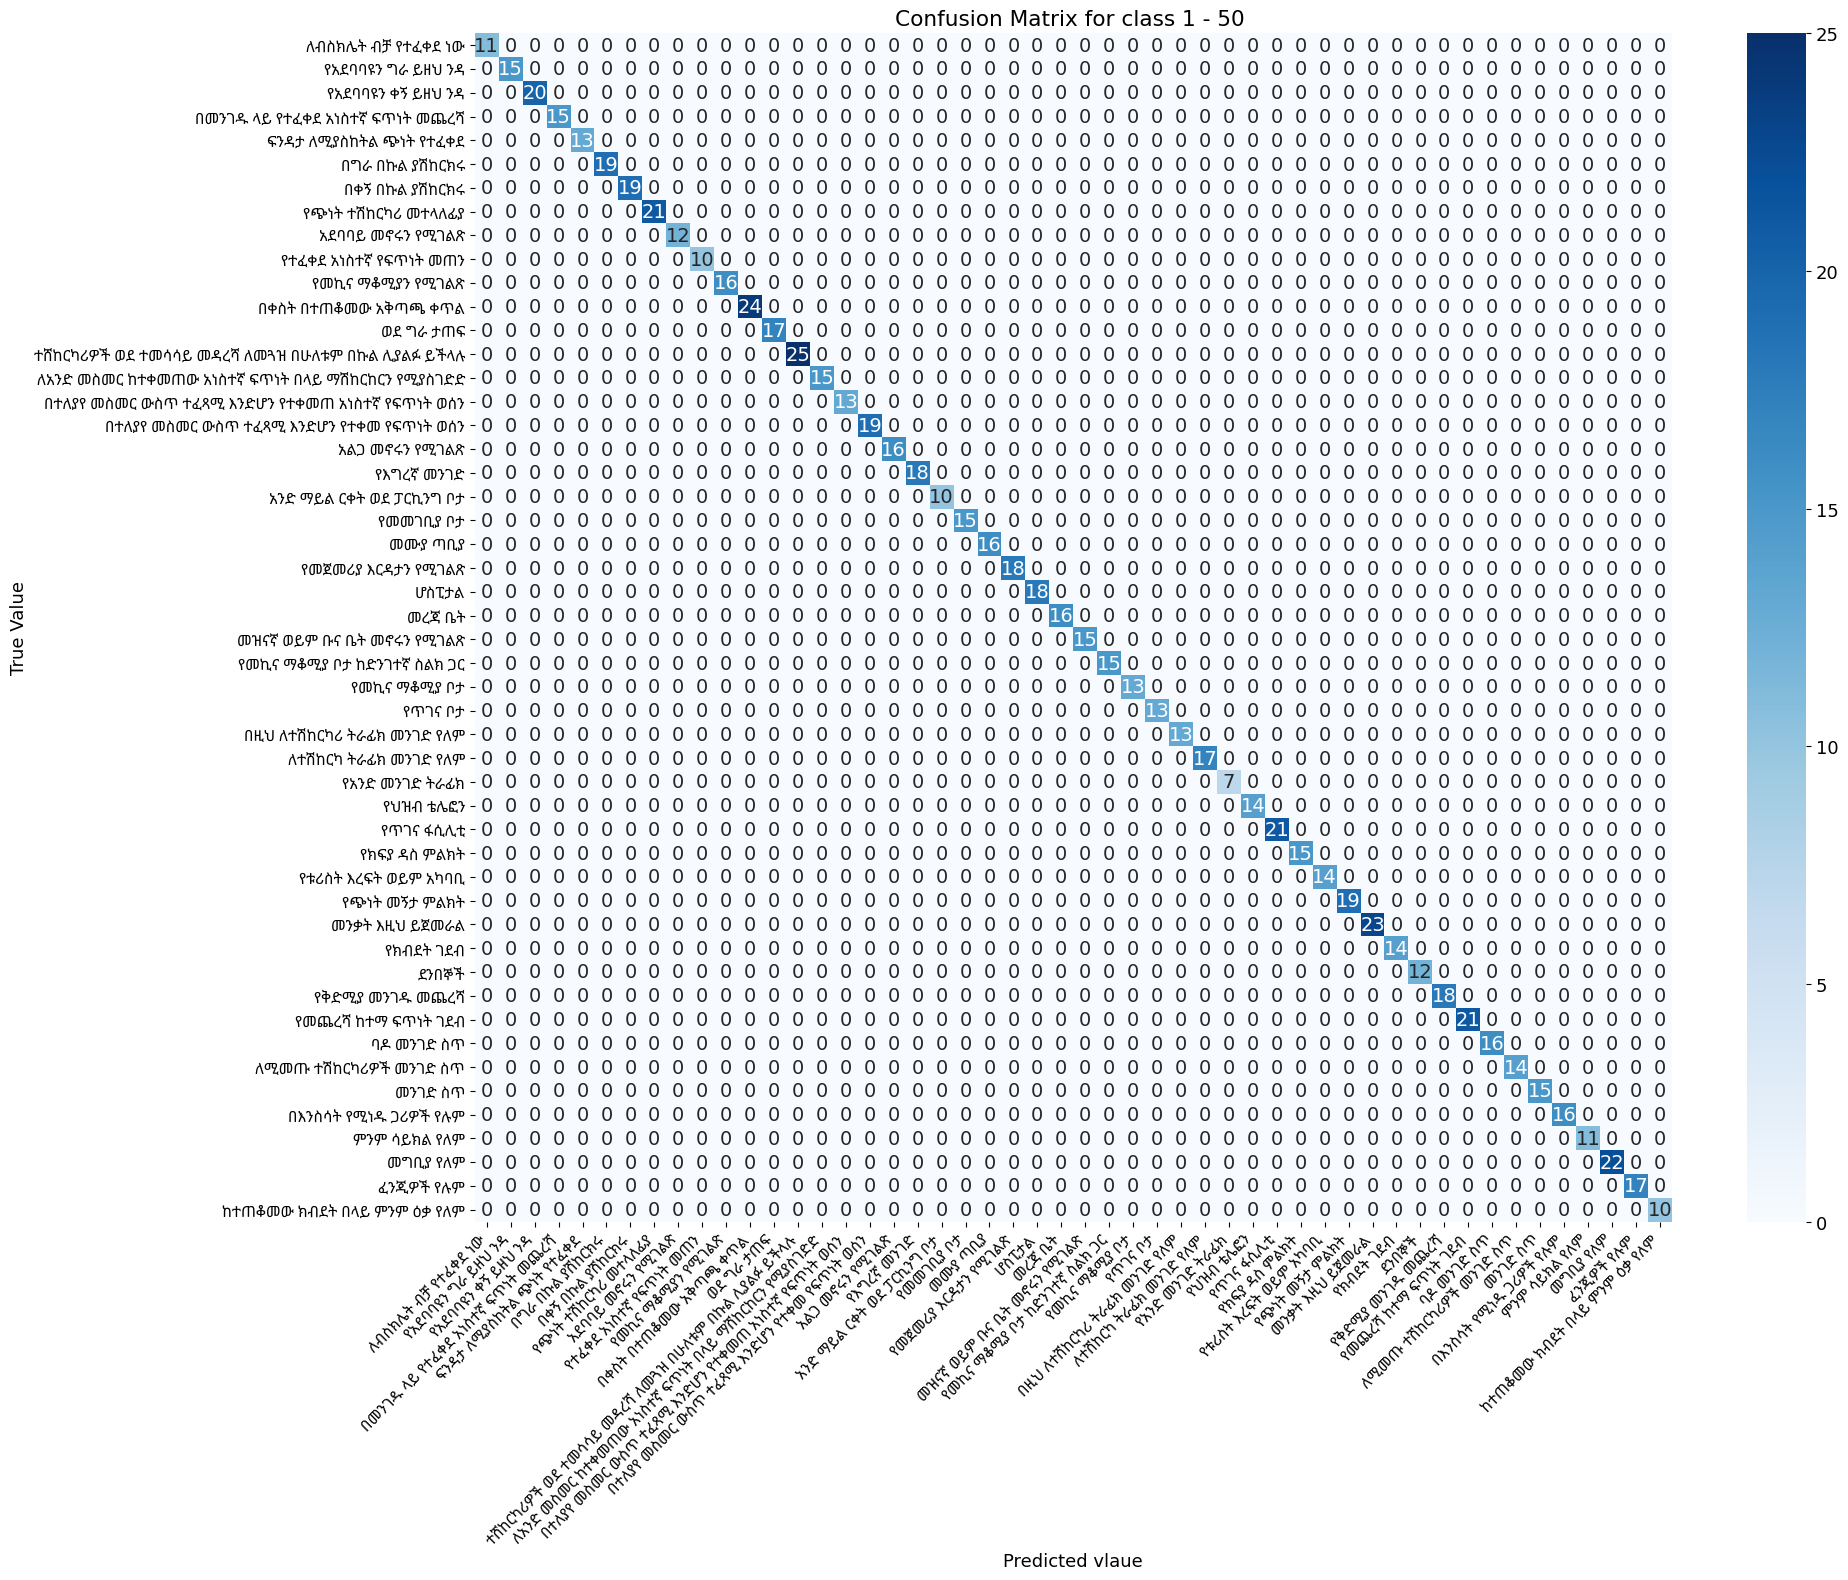

time: 8.11 s (started: 2025-10-25 07:25:43 +00:00)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.font_manager as fm
import tensorflow as tf

# === Load Amharic Font ===
font_path = '/usr/share/fonts/truetype/noto/NotoSansEthiopic-Regular.ttf'
# font_path = '/usr/share/fonts/truetype/noto/NotoSans-Regular.ttf'
ethio_font = fm.FontProperties(fname=font_path, size=11)

with tf.device('/gpu:0'):
    # Convert predictions and ground truth
    y_true_classes = np.argmax(y_test, axis=1)
    y_pred_classes = np.argmax(mobilenet.predict([X_test, X_test]), axis=1)

    # Compute confusion matrix
    cm = confusion_matrix(y_true_classes, y_pred_classes)

    # Select a subset of classes to make it readable
    start_idx, end_idx = 0, 50  # change as needed
    cm_subset = cm[np.ix_(range(start_idx, end_idx), range(start_idx, end_idx))]
    class_labels_subset = class_names[start_idx:end_idx]  # your Amharic class names
    # === Replace underscores with spaces ===
    class_labels_subset = [name.replace('_', ' ') for name in class_labels_subset]

    # Plot
    plt.figure(figsize=(20, 16))
    ax = sns.heatmap(cm_subset, annot=True, fmt="d", cmap="Blues",
                     xticklabels=class_labels_subset,
                     yticklabels=class_labels_subset,
                     cbar=True,annot_kws={"size": 14})

    # Set Amharic labels for axes and title
    ax.set_xlabel("Predicted vlaue")  # Predicted Label
    ax.set_ylabel("True Value")  # True Label
    ax.set_title("Confusion Matrix for class 1 - 50 ")

    # Rotate x-ticks for readability
    plt.xticks(rotation=45, ha="right", fontproperties=ethio_font)
    plt.yticks(fontproperties=ethio_font)
    plt.tight_layout()
    plt.show()






---



In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model_with_new_input)
tflite_model = converter.convert()

open("correctedtraffic.tflite", 'wb').write(tflite_model)

In [ ]:
labels_tflite =['ለብስክሌት_ብቻ_የተፈቀደ_ነው',	'የአደባባዩን_ግራ_ይዘህ_ንዳ',	'የአደባባዩን_ቀኝ_ይዘህ_ንዳ',	'በመንገዱ_ላይ_የተፈቀደ_አነስተኛ_ፍጥነት_መጨረሻ',
                        'ፍንዳታ_ለሚያስከትል_ጭነት_የተፈቀደ',	'በግራ_በኩል_ያሽከርክሩ',	'በቀኝ_በኩል_ያሽከርክሩ',	'የጭነት_ተሽከርካሪ_መተላለፊያ',	'አደባባይ_መኖሩን_የሚገልጽ',
                        'የተፈቀደ_አነስተኛ_የፍጥነት_መጠን',	'የመኪና_ማቆሚያን_የሚገልጽ',	'በቀስት_በተጠቆመው_አቅጣጫ_ቀጥል',
                        'ወደ_ግራ_ታጠፍ',	'ተሸከርካሪዎች_ወደ_ተመሳሳይ_መዳረሻ_ለመጓዝ_በሁለቱም_በኩል_ሊያልፉ_ይችላሉ',
                        'ለአንድ_መስመር_ከተቀመጠው_አነስተኛ_ፍጥነት_በላይ_ማሽከርከርን_የሚያስገድድ',
                        'በተለያየ_መስመር_ውስጥ_ተፈጻሚ_እንድሆን_የተቀመጠ_አነስተኛ_የፍጥነት_ወሰን',	'በተለያየ_መስመር_ውስጥ_ተፈጻሚ_እንድሆን_የተቀመ_የፍጥነት_ወሰን',
                        'አልጋ_መኖሩን_የሚገልጽ',	'የእግረኛ_መንገድ',	'አንድ_ማይል_ርቀት_ወደ_ፓርኪንግ_ቦታ',	'የመመገቢያ_ቦታ',	'መሙያ_ጣቢያ',	'የመጀመሪያ_እርዳታን_የሚገልጽ',
                        'ሆስፒታል',	'መረጃ_ቤት',	'መዝናኛ_ወይም_ቡና_ቤት_መኖሩን_የሚገልጽ',	'የመኪና_ማቆሚያ_ቦታ_ከድንገተኛ_ስልክ_ጋር',	'የመኪና_ማቆሚያ_ቦታ',
                        'የጥገና_ቦታ',	'በዚህ_ለተሽከርካሪ_ትራፊክ_መንገድ_የለም',	'ለተሽከርካ_ትራፊክ_መንገድ_የለም',	'የአንድ_መንገድ_ትራፊክ',
                        'የህዝብ_ቴሌፎን',	'የጥገና_ፋሲሊቲ',	'የክፍያ_ዳስ_ምልክት',	'የቱሪስት_እረፍት_ወይም_አካባቢ',	'የጭነት_መኝታ_ምልክት',	'መንቃት_እዚህ_ይጀመራል',
                        'የክብደት_ገደብ',	'ደንበኞች',	'የቅድሚያ_መንገዱ_መጨረሻ',	'የመጨረሻ_ከተማ_ፍጥነት_ገደብ',	'ባዶ_መንገድ_ስጥ',	'ለሚመጡ_ተሽከርካሪዎች_መንገድ_ስጥ',
                        'መንገድ_ስጥ',	'በእንስሳት_የሚነዱ_ጋሪዎች_የሉም',	'ምንም_ሳይክል_የለም',	'መግቢያ_የለም',	'ፈንጂዎች_የሉም',	'ከተጠቆመው_ክብደት_በላይ_ምንም_ዕቃ_የለም',
                        'በእጅ_የሚነዳ_ጋሪ_የለም',	'ጥሩምባ_የለም','ወደ_ግራ_መታጠፍ_የተከለከለ',	'ለተጫነ_ተሽከርካሪ_ማለፍ_የለም',	'ምንም_ተሽከርካሪ_ከሶሎ_ሞተር_ሳይክል_በስተቀር',	'ምንም_ሞተር_ተሽከርካሪ',
                        'ከሁለት_እግር_በላይ_ያላቸው_ተሽከርካሪዎች_መቅደም_የተከለከለ',	'የመኪና_ማቆሚያ_የለም',	'እግረኞች_የሉም',	'ወደ_ቀኝ_መታጠፍ_የተከለከለ',	'ብቸኛ_ሞተር_ሳይክል_የለም',
                        'ማቆም_የለም',	'የሚጎተት_መኪና_የለም',	'የተጎተቱ_ካራቫስ_የለም',	'የከተማ_ክልል',	'ወደ_U_ግራ_መታጠፍ_የለም',	'ወደ_U_ቀኝ_መታጠፍ_የለም',
                        'ምንም_የተሽከርካሪ_እጀታ_ጭነት_በላይ_አልተገለጸም',	'ከ20_ቶን_በላይ_ተሽከርካሪ_የተከለከለ',	'ተሽከርካሪ_የለም',	'ከከፍተኛው_ወርድ_በላይ_ምንም_ተሽከርካሪ_አይታይም',
                        'ከተገለጸው_ርዝመት_በላይ_የተከለከለ',	'ከሚታየው_ከፍታ_በላይ_ምንም_ተሽከርካሪ_ማለፍ_አይችልም',	'የመጠበቅ_መጨረሻ',	'አይጠበቅም',	'ቅድሚያ_መንገድ',	'ገደብ_አልቋል',
                        'መስቀለኛ_መንገድ_ከመግባትህ_በፊት_አቁም',	'አቁም',	'ከፍተኛው_ፍጥነት',	'መኪና_አለ',	'ወደግራ_ታጠፍ',	'ወደ_ቀኝ_ታጠፍ',	'ጋሪዎች_ከፊት_አሉ',
                        'የቁልቁል_ማርከሮች',	'መስቀለኛ_መንገድ',	'የአካል_ጉዳተኛ_ሰው',	'ድርብ_ታጠፍ',	'ድርብ_ቁልቁል_ማርከሮች',	'በጥንቃቄ_መንዳት',	'የአስፋልት_መንገድ_መጨረሻ',
                        'የድልድይ_ግድግዳ_መጨረሻ',	'የሁለት_ጋሪ_መንገድ_መጨረሻ',	'በሁለት_የተከፈለ_መንገድ_መጨረሻ',	'የእርሻ_ማሽን_የሚገልጽ_1',	'የእርሻ_ማሽን_የሚገልጽ_2',
                        'ከፊት_ቀያሽ_አለ',	'መጀመሪያ_ግራ_ከዚያ_ቀጥታ_ታጠፍ',	'መጀመሪያ_ቀኝ_ከዚያ_ቀጥታ_ታጠፍ',	'ከውሃ_እስከ_አስፋልት_መንገድ',	'ለባቡር_ሎኮሞቲቭ_መንገድ_ስጥ',
                        'ጎባጣ_ድልድይ',	'የቤት_እንስሳት',	'ከታጣፊ_መንገድ_ላይ_የሚገነጠል',	'የሚጫወቱ_ልጆች',	'ደረጃ_በእንቅፋት_መሻገር',	'የተጫነ_ደረቅ_ተሽከርካሪ_ከፊት',	'ወንዶች_በስራ_ ላይ',
                        'ጠባብ_ድልድይ',	'በመንገዳው_በሁለት_መንገድ_ተከፈለ',	'ከፍት_ወይም_ዳገታማ_ድልድይ_ከፊት',	'ማረሻ_የእርሻ_ተሽከርካሪ_ከፊት',	'ወንዝ_ዳር',
                        'ተከታታይ_መኪና',	'ድርብ_የባቡር_መስመር',	'ባቡር_በስተግራ_ይሻገራል',	'ባቡር_በስተቀኝ_ይሻገራል',	'ነጠላ_የባቡር_አቋራጭ',	'በመንገዱ_አቋራጭ_የባቡር_ሎኮሞቲቭ',	'የባቡር_መሻገሪያ_T',
                        'የመውደቅ_ወይም_የመውደቅ_ስጋት_መንገድ',	'የመንገድ_ጉብታዎች',	'በሁለቱም_ጎን_መንገዱ_ይጠባል',	'መንገዱ_በቀኝ_ይጠባል',	'መንገድ_ከኪሳራ_ጋር',	'የመንገድ_ስራ_ከፊት',
                        'ክብ_ዙር',	'ትምህርት_ቤት',	'የመንገዱን_ወደ_ግራ_ጥርት_ማዘዋወር',	'የመንገዱን_አቅጣጫ_አጥራ',	'የጎን_መንገድ_ቅርንጫፍ_ግራ',	'የጎን_መንገድ_ቅርንጫፍ_ቀኝ',	'የግራ_ጎን_መንገድ',
                        'ሰያፍ_የቀኝ_ጎን_መንገድ',	'የጎን_መንገድ_ቀኝ',	'ተንሸራታች_መንገድ',	'ሁለት_መንታ_ያለው_መንገድ',	'ቁልቁል_ዳገት_ወደታች',	'ቁልቁል_ዳገት_ወደላይ',	'አመላካች',	'T_ቅርጽ_ያለው_መንገድ',
                        'T_ቅርጽ',	'በግራ_በኩል_የሚዋሃድ_መንገድ_አለ',	'ከፊት_የትራፊክ_ምልክቶች_አሉ',	'ትራም_በመንገድ_ላይ',	'የሁለት_መንገድ_ትራፊክ_በፊት_ማቋረጫ_ላይ',
                        'ባለሁለት_መንገድ_ትራፊክ',	'ያልተስተካከለ_መንገድ',	'የማስጠንቀቂያ_ቀስት_እና_መሰጠት_ውስጥ',	'የማስጠንቀቂያ_ቀስት_ወደፊት_ይቆማል',	'የውሃ_ኮርስ_በመንገድ_ዳር',
                        'የዱር_እንስሳት',	'ነፋስ',	'y_መገናኛ',	'የዜብራ_መንገድ',	'ዝግዛግ_መንገድ']
with open('traffic_label.txt','w') as f:
  f.write('\n'.join(labels_tflite))

# **VGG16 Base model**

In [ ]:
from keras import models
from keras import layers

#Load the VGG model
IMAGE_SIZE=[64,64]
base_vgg = VGG16(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

# Freeze the layers except the last 2 layers
for layer in base_vgg.layers:
  layer.trainable = False

# Create the model
with tf.device('/gpu:0'):
  base_vggnet = tf.keras.models.Sequential()
  base_vggnet.add(base_vgg)
  base_vggnet.add(layers.Flatten(name='flatten'))
  base_vggnet.add(layers.Dense(4096, activation='relu', name='fc1'))
  base_vggnet.add(layers.Dense(4096, activation='relu', name='fc2'))
  base_vggnet.add(layers.Dense(156, activation='softmax', name='predictions'))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
lr = 0.0001
epoch = 150
with tf.device('/gpu:0'):
  early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',      # Metric to monitor
    mode='max',
    patience=5,             # Wait 10 epochs without improvement
    verbose=1,
    restore_best_weights=True)
  opt =  tf.keras.optimizers.Adamax(learning_rate  = lr, decay = 1e-6)
  base_vggnet.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
  BVGG = base_vggnet.fit(X_train, y_train, epochs=epoch, validation_split = 0.1, batch_size=32, callbacks=[early_stop])

/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Epoch 1/150
248/248 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.2870 - loss: 3.4774 - val_accuracy: 0.4898 - val_loss: 2.3769
Epoch 2/150
248/248 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5500 - loss: 1.9864 - val_accuracy: 0.5909 - val_loss: 1.7131
Epoch 3/150
248/248 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6655 - loss: 1.4388 - val_accuracy: 0.6955 - val_loss: 1.2967
Epoch 4/150
248/248 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.7375 - loss: 1.1136 - val_accuracy: 0.7295 - val_loss: 1.0607
Epoch 5/150
248/248 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7972 - loss: 0.8666 - val_accuracy: 0.7977 - val_loss: 0.8443
Epoch 6/150
248/248 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.8360 - loss: 0.7024 - val_accuracy: 0.8295 - val_loss: 0.6968
Epoch 7/150
248/248 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.8683 - loss: 0.5707 - val_accuracy: 0.8250 - val_loss: 0.6197
Epoch 8/150
248/248 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.8875 - loss: 0.4747 -

In [ ]:
# Find train and test accuracy
with tf.device('/gpu:0'):
  loss, accuracy = vggnet.evaluate(X_train, y_train, verbose=False)
  print("Training Accuracy: {:.2f}".format(accuracy*100))
  print("Training loss: {:.2f}".format(loss*100))
  loss, accuracy = vggnet.evaluate(X_test, y_test, verbose=False)
  print("Testing Accuracy:  {:.2f}".format(accuracy*100))
  print("Testing loss:  {:.2f}".format(loss*100))
  # print("Training time:", time.time()-t0)


**VGG16 graphs**
---



In [ ]:
# plot the training loss and accuracy
plt.style.use("ggplot")
plt.figure()
N = 100
plt.rcParams['font.size'] = '12'
plt.rcParams['font.weight'] = 'bold'


plt.plot(BVGG.history["accuracy"], 'b', label="base VGG16-train acc")
plt.plot(BVGG.history["val_accuracy"], 'g', label="base VGG16-test acc")


plt.plot(VGG.history["accuracy"], 'skyblue', label="tuned VGG16-train acc")
plt.plot(VGG.history["val_accuracy"], 'purple', label="tuned VGG16-test acc")

plt.xlabel('font', weight='bold')
plt.ylabel('font', weight='bold')
plt.title('font', weight='bold')
plt.title("Training & Testing Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Accuracy")
plt.legend(loc="lower right")
plt.savefig('accuracy.png')

In [ ]:
# plot the training loss and accuracy
plt.style.use("ggplot")
plt.figure()
N = 100
plt.rcParams['font.size'] = '12'
plt.rcParams['font.weight'] = 'bold'


plt.plot(BVGG.history["loss"], 'yellow',label="base vgg16-train loss")
plt.plot(BVGG.history["val_loss"], 'r', label="base vgg16-test loss")

plt.plot(VGG.history["loss"], 'brown', label="tuned vgg16-train loss")
plt.plot(VGG.history["val_loss"], 'orange', label="tuned vgg16-test loss")

plt.xlabel('font', weight='bold')
plt.ylabel('font', weight='bold')
plt.title('font', weight='bold')
plt.title("Training & Testing Loss")
plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.legend(loc="upper right")
# plt.ylim(0,0.3)
plt.savefig('loss.png')

# **VGG16 Net** **Confusion** **Matrix**

In [ ]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
# from sklearn.utils.multi_label import unique_labels
from sklearn.utils.multiclass import unique_labels
plt.rcParams['font.size'] = '13'
# Get predicted values
y_pred = base_vggnet.predict(X_test)  # outputs probabilities of each classes
# Create empty numpy array to match length of training data
y_pred_array = np.zeros(X_test.shape[0])
plt.rcParams['font.size'] = '13'
# Find class with highest probability
for i in range(0, y_pred.shape[0]):
    label_predict = np.argmax(y_pred[i]) # column with max probability
    y_pred_array[i] = label_predict

# convert to integers
y_pred_array = y_pred_array.astype(int)

# Convert y_test to 1d numpy array
y_test_array = np.zeros(X_test.shape[0])

# Find class with 1
for i in range(0, y_test.shape[0]):
    label_predict = np.argmax(y_test[i])
    y_test_array[i] = label_predict

y_test_array = y_test_array.astype(int)
# class_names = np.array(['ለብስክሌት_ብቻ_የተፈቀደ_ነው',	'የአደባባዩን_ግራ_ይዘህ_ንዳ',	'የአደባባዩን_ቀኝ_ይዘህ_ንዳ',	'በመንገዱ_ላይ_የተፈቀደ_አነስተኛ_ፍጥነት_መጨረሻ',
#                         'ፍንዳታ_ለሚያስከትል_ጭነት_የተፈቀደ',	'በግራ_በኩል_ያሽከርክሩ',	'በቀኝ_በኩል_ያሽከርክሩ',	'የጭነት_ተሽከርካሪ_መተላለፊያ',	'አደባባይ_መኖሩን_የሚገልጽ',
#                         'የተፈቀደ_አነስተኛ_የፍጥነት_መጠን',	'የመኪና_ማቆሚያን_የሚገልጽ',	'በቀስት_በተጠቆመው_አቅጣጫ_ቀጥል',
#                         'ወደ_ግራ_ታጠፍ',	'ተሸከርካሪዎች_ወደ_ተመሳሳይ_መዳረሻ_ለመጓዝ_በሁለቱም_በኩል_ሊያልፉ_ይችላሉ',
#                         'ለአንድ_መስመር_ከተቀመጠው_አነስተኛ_ፍጥነት_በላይ_ማሽከርከርን_የሚያስገድድ',
#                         'በተለያየ_መስመር_ውስጥ_ተፈጻሚ_እንድሆን_የተቀመጠ_አነስተኛ_የፍጥነት_ወሰን',	'በተለያየ_መስመር_ውስጥ_ተፈጻሚ_እንድሆን_የተቀመ_የፍጥነት_ወሰን',
#                         'አልጋ_መኖሩን_የሚገልጽ',	'የእግረኛ_መንገድ',	'አንድ_ማይል_ርቀት_ወደ_ፓርኪንግ_ቦታ',	'የመመገቢያ_ቦታ',	'መሙያ_ጣቢያ',	'የመጀመሪያ_እርዳታን_የሚገልጽ',
#                         'ሆስፒታል',	'መረጃ_ቤት',	'መዝናኛ_ወይም_ቡና_ቤት_መኖሩን_የሚገልጽ',	'የመኪና_ማቆሚያ_ቦታ_ከድንገተኛ_ስልክ_ጋር',	'የመኪና_ማቆሚያ_ቦታ',
#                         'የጥገና_ቦታ',	'በዚህ_ለተሽከርካሪ_ትራፊክ_መንገድ_የለም',	'ለተሽከርካ_ትራፊክ_መንገድ_የለም',	'የአንድ_መንገድ_ትራፊክ',
#                         'የህዝብ_ቴሌፎን',	'የጥገና_ፋሲሊቲ',	'የክፍያ_ዳስ_ምልክት',	'የቱሪስት_እረፍት_ወይም_አካባቢ',	'የጭነት_መኝታ_ምልክት',	'መንቃት_እዚህ_ይጀመራል',
#                         'የክብደት_ገደብ',	'ደንበኞች',	'የቅድሚያ_መንገዱ_መጨረሻ',	'የመጨረሻ_ከተማ_ፍጥነት_ገደብ',	'ባዶ_መንገድ_ስጥ',	'ለሚመጡ_ተሽከርካሪዎች_መንገድ_ስጥ',
#                         'መንገድ_ስጥ',	'በእንስሳት_የሚነዱ_ጋሪዎች_የሉም',	'ምንም_ሳይክል_የለም',	'መግቢያ_የለም',	'ፈንጂዎች_የሉም',	'ከተጠቆመው_ክብደት_በላይ_ምንም_ዕቃ_የለም',
#                         'በእጅ_የሚነዳ_ጋሪ_የለም',	'ጥሩምባ_የለም','ወደ_ግራ_መታጠፍ_የተከለከለ',	'ለተጫነ_ተሽከርካሪ_ማለፍ_የለም',	'ምንም_ተሽከርካሪ_ከሶሎ_ሞተር_ሳይክል_በስተቀር',	'ምንም_ሞተር_ተሽከርካሪ',
#                         'ከሁለት_እግር_በላይ_ያላቸው_ተሽከርካሪዎች_መቅደም_የተከለከለ',	'የመኪና_ማቆሚያ_የለም',	'እግረኞች_የሉም',	'ወደ_ቀኝ_መታጠፍ_የተከለከለ',	'ብቸኛ_ሞተር_ሳይክል_የለም',
#                         'ማቆም_የለም',	'የሚጎተት_መኪና_የለም',	'የተጎተቱ_ካራቫስ_የለም',	'የከተማ_ክልል',	'ወደ_U_ግራ_መታጠፍ_የለም',	'ወደ_U_ቀኝ_መታጠፍ_የለም',
#                         'ምንም_የተሽከርካሪ_እጀታ_ጭነት_በላይ_አልተገለጸም',	'ከ20_ቶን_በላይ_ተሽከርካሪ_የተከለከለ',	'ተሽከርካሪ_የለም',	'ከከፍተኛው_ወርድ_በላይ_ምንም_ተሽከርካሪ_አይታይም',
#                         'ከተገለጸው_ርዝመት_በላይ_የተከለከለ',	'ከሚታየው_ከፍታ_በላይ_ምንም_ተሽከርካሪ_ማለፍ_አይችልም',	'የመጠበቅ_መጨረሻ',	'አይጠበቅም',	'ቅድሚያ_መንገድ',	'ገደብ_አልቋል',
#                         'መስቀለኛ_መንገድ_ከመግባትህ_በፊት_አቁም',	'አቁም',	'ከፍተኛው_ፍጥነት',	'መኪና_አለ',	'ወደግራ_ታጠፍ',	'ወደ_ቀኝ_ታጠፍ',	'ጋሪዎች_ከፊት_አሉ',
#                         'የቁልቁል_ማርከሮች',	'መስቀለኛ_መንገድ',	'የአካል_ጉዳተኛ_ሰው',	'ድርብ_ታጠፍ',	'ድርብ_ቁልቁል_ማርከሮች',	'በጥንቃቄ_መንዳት',	'የአስፋልት_መንገድ_መጨረሻ',
#                         'የድልድይ_ግድግዳ_መጨረሻ',	'የሁለት_ጋሪ_መንገድ_መጨረሻ',	'በሁለት_የተከፈለ_መንገድ_መጨረሻ',	'የእርሻ_ማሽን_የሚገልጽ_1',	'የእርሻ_ማሽን_የሚገልጽ_2',
#                         'ከፊት_ቀያሽ_አለ',	'መጀመሪያ_ግራ_ከዚያ_ቀጥታ_ታጠፍ',	'መጀመሪያ_ቀኝ_ከዚያ_ቀጥታ_ታጠፍ',	'ከውሃ_እስከ_አስፋልት_መንገድ',	'ለባቡር_ሎኮሞቲቭ_መንገድ_ስጥ',
#                         'ጎባጣ_ድልድይ',	'የቤት_እንስሳት',	'ከታጣፊ_መንገድ_ላይ_የሚገነጠል',	'የሚጫወቱ_ልጆች',	'ደረጃ_በእንቅፋት_መሻገር',	'የተጫነ_ደረቅ_ተሽከርካሪ_ከፊት',	'ወንዶች_በስራ_ ላይ',
#                         'ጠባብ_ድልድይ',	'በመንገዳው_በሁለት_መንገድ_ተከፈለ',	'ከፍት_ወይም_ዳገታማ_ድልድይ_ከፊት',	'ማረሻ_የእርሻ_ተሽከርካሪ_ከፊት',	'ወንዝ_ዳር',
#                         'ተከታታይ_መኪና',	'ድርብ_የባቡር_መስመር',	'ባቡር_በስተግራ_ይሻገራል',	'ባቡር_በስተቀኝ_ይሻገራል',	'ነጠላ_የባቡር_አቋራጭ',	'በመንገዱ_አቋራጭ_የባቡር_ሎኮሞቲቭ',	'የባቡር_መሻገሪያ_T',
#                         'የመውደቅ_ወይም_የመውደቅ_ስጋት_መንገድ',	'የመንገድ_ጉብታዎች',	'በሁለቱም_ጎን_መንገዱ_ይጠባል',	'መንገዱ_በቀኝ_ይጠባል',	'መንገድ_ከኪሳራ_ጋር',	'የመንገድ_ስራ_ከፊት',
#                         'ክብ_ዙር',	'ትምህርት_ቤት',	'የመንገዱን_ወደ_ግራ_ጥርት_ማዘዋወር',	'የመንገዱን_አቅጣጫ_አጥራ',	'የጎን_መንገድ_ቅርንጫፍ_ግራ',	'የጎን_መንገድ_ቅርንጫፍ_ቀኝ',	'የግራ_ጎን_መንገድ',
#                         'ሰያፍ_የቀኝ_ጎን_መንገድ',	'የጎን_መንገድ_ቀኝ',	'ተንሸራታች_መንገድ',	'ሁለት_መንታ_ያለው_መንገድ',	'ቁልቁል_ዳገት_ወደታች',	'ቁልቁል_ዳገት_ወደላይ',	'አመላካች',	'T_ቅርጽ_ያለው_መንገድ',
#                         'T_ቅርጽ',	'በግራ_በኩል_የሚዋሃድ_መንገድ_አለ',	'ከፊት_የትራፊክ_ምልክቶች_አሉ',	'ትራም_በመንገድ_ላይ',	'የሁለት_መንገድ_ትራፊክ_በፊት_ማቋረጫ_ላይ',
#                         'ባለሁለት_መንገድ_ትራፊክ',	'ያልተስተካከለ_መንገድ',	'የማስጠንቀቂያ_ቀስት_እና_መሰጠት_ውስጥ',	'የማስጠንቀቂያ_ቀስት_ወደፊት_ይቆማል',	'የውሃ_ኮርስ_በመንገድ_ዳር',
#                         'የዱር_እንስሳት',	'ነፋስ',	'y_መገናኛ',	'የዜብራ_መንገድ',	'ዝግዛግ_መንገድ'])

# def plot_confusion_matrix(y_true, y_pred, classes,
#                           normalize=False,
#                           title=None,
#                           cmap=plt.cm.Blues):
#   # This function prints and plots the confusion matrix. Normalization can be applied by setting `normalize=True`."""
#   if not title:
#     if normalize:
#       title = 'Normalized confusion matrix'
#     else:
#       title = 'Confusion matrix'


#   # Compute confusion matrix
#   cm = confusion_matrix(y_true, y_pred)
#   # Only use the labels that appear in the data
#   classes = classes[unique_labels(y_true, y_pred)]
#   if normalize:
#     cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]*100
#     print("Normalized confusion matrix")
#   else:
#     print('Confusion matrix')
#   print(cm)
#   fig, ax = plt.subplots(figsize=(8,8))
#   im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
#   ax.figure.colorbar(im, ax=ax)
#   # We want to show all ticks
#   ax.set(xticks=np.arange(cm.shape[1]),
#          yticks=np.arange(cm.shape[0]),
#          # ... and label them with the respective list entries
#          xticklabels=classes, yticklabels=classes,
#          title=title,
#          ylabel='True label',
#          xlabel='Predicted label')
#   # Rotate the tick labels and set their alignment.
#   #plt.setp('font', weight='bold')
#   plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
#   # Loop over data dimensions and create text annotations.
#   fmt = '.2f' if normalize else 'd'
#   thresh = cm.max() / 2.
#   for i in range(cm.shape[0]):
#     for j in range(cm.shape[1]):
#       ax.text(j, i, format(cm[i, j], fmt),
#               ha="center", va="center",
#               color="white" if cm[i, j] > thresh else "black")
#   fig.tight_layout()
#   return ax
# np.set_printoptions(precision=2)
# plt.figure(figsize=(170,170))
# # Plot non-normalized confusion matrix
# plot_confusion_matrix(y_test_array, y_pred_array, classes=class_names,
#                       title='Confusion matrix')
# plt.grid(False)

# # Plot normalized confusion matrix
# plot_confusion_matrix(y_test_array, y_pred_array, classes=class_names, normalize=True,
#                       title='Normalized confusion matrix')
# plt.grid(False)

# plt.show()



69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step


classification report

In [ ]:
#classification report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
# from sklearn.utils.multi_label import unique_labels
from sklearn.utils.multiclass import unique_labels
plt.rcParams['font.size'] = '13'
# Get predicted values
y_pred = vggnet.predict(X_test)  # outputs probabilities of each classes
# Create empty numpy array to match length of training data
y_pred_array = np.zeros(X_test.shape[0])
plt.rcParams['font.size'] = '13'
# Find class with highest probability
for i in range(0, y_pred.shape[0]):
    label_predict = np.argmax(y_pred[i]) # column with max probability
    y_pred_array[i] = label_predict

# convert to integers
y_pred_array = y_pred_array.astype(int)

# Convert y_test to 1d numpy array
y_test_array = np.zeros(X_test.shape[0])

# Find class with 1
for i in range(0, y_test.shape[0]):
    label_predict = np.argmax(y_test[i])
    y_test_array[i] = label_predict

y_test_array = y_test_array.astype(int)
# print(confusion_matrix(y_test_array, y_pred_array))
target_names = ['ለብስክሌት_ብቻ_የተፈቀደ_ነው',	'የአደባባዩን_ግራ_ይዘህ_ንዳ',	'የአደባባዩን_ቀኝ_ይዘህ_ንዳ',	'በመንገዱ_ላይ_የተፈቀደ_አነስተኛ_ፍጥነት_መጨረሻ',
                        'ፍንዳታ_ለሚያስከትል_ጭነት_የተፈቀደ',	'በግራ_በኩል_ያሽከርክሩ',	'በቀኝ_በኩል_ያሽከርክሩ',	'የጭነት_ተሽከርካሪ_መተላለፊያ',	'አደባባይ_መኖሩን_የሚገልጽ',
                        'የተፈቀደ_አነስተኛ_የፍጥነት_መጠን',	'የመኪና_ማቆሚያን_የሚገልጽ',	'በቀስት_በተጠቆመው_አቅጣጫ_ቀጥል',
                        'ወደ_ግራ_ታጠፍ',	'ተሸከርካሪዎች_ወደ_ተመሳሳይ_መዳረሻ_ለመጓዝ_በሁለቱም_በኩል_ሊያልፉ_ይችላሉ',
                        'ለአንድ_መስመር_ከተቀመጠው_አነስተኛ_ፍጥነት_በላይ_ማሽከርከርን_የሚያስገድድ',
                        'በተለያየ_መስመር_ውስጥ_ተፈጻሚ_እንድሆን_የተቀመጠ_አነስተኛ_የፍጥነት_ወሰን',	'በተለያየ_መስመር_ውስጥ_ተፈጻሚ_እንድሆን_የተቀመ_የፍጥነት_ወሰን',
                        'አልጋ_መኖሩን_የሚገልጽ',	'የእግረኛ_መንገድ',	'አንድ_ማይል_ርቀት_ወደ_ፓርኪንግ_ቦታ',	'የመመገቢያ_ቦታ',	'መሙያ_ጣቢያ',	'የመጀመሪያ_እርዳታን_የሚገልጽ',
                        'ሆስፒታል',	'መረጃ_ቤት',	'መዝናኛ_ወይም_ቡና_ቤት_መኖሩን_የሚገልጽ',	'የመኪና_ማቆሚያ_ቦታ_ከድንገተኛ_ስልክ_ጋር',	'የመኪና_ማቆሚያ_ቦታ',
                        'የጥገና_ቦታ',	'በዚህ_ለተሽከርካሪ_ትራፊክ_መንገድ_የለም',	'ለተሽከርካ_ትራፊክ_መንገድ_የለም',	'የአንድ_መንገድ_ትራፊክ',
                        'የህዝብ_ቴሌፎን',	'የጥገና_ፋሲሊቲ',	'የክፍያ_ዳስ_ምልክት',	'የቱሪስት_እረፍት_ወይም_አካባቢ',	'የጭነት_መኝታ_ምልክት',	'መንቃት_እዚህ_ይጀመራል',
                        'የክብደት_ገደብ',	'ደንበኞች',	'የቅድሚያ_መንገዱ_መጨረሻ',	'የመጨረሻ_ከተማ_ፍጥነት_ገደብ',	'ባዶ_መንገድ_ስጥ',	'ለሚመጡ_ተሽከርካሪዎች_መንገድ_ስጥ',
                        'መንገድ_ስጥ',	'በእንስሳት_የሚነዱ_ጋሪዎች_የሉም',	'ምንም_ሳይክል_የለም',	'መግቢያ_የለም',	'ፈንጂዎች_የሉም',	'ከተጠቆመው_ክብደት_በላይ_ምንም_ዕቃ_የለም',
                        'በእጅ_የሚነዳ_ጋሪ_የለም',	'ጥሩምባ_የለም','ወደ_ግራ_መታጠፍ_የተከለከለ',	'ለተጫነ_ተሽከርካሪ_ማለፍ_የለም',	'ምንም_ተሽከርካሪ_ከሶሎ_ሞተር_ሳይክል_በስተቀር',	'ምንም_ሞተር_ተሽከርካሪ',
                        'ከሁለት_እግር_በላይ_ያላቸው_ተሽከርካሪዎች_መቅደም_የተከለከለ',	'የመኪና_ማቆሚያ_የለም',	'እግረኞች_የሉም',	'ወደ_ቀኝ_መታጠፍ_የተከለከለ',	'ብቸኛ_ሞተር_ሳይክል_የለም',
                        'ማቆም_የለም',	'የሚጎተት_መኪና_የለም',	'የተጎተቱ_ካራቫስ_የለም',	'የከተማ_ክልል',	'ወደ_U_ግራ_መታጠፍ_የለም',	'ወደ_U_ቀኝ_መታጠፍ_የለም',
                        'ምንም_የተሽከርካሪ_እጀታ_ጭነት_በላይ_አልተገለጸም',	'ከ20_ቶን_በላይ_ተሽከርካሪ_የተከለከለ',	'ተሽከርካሪ_የለም',	'ከከፍተኛው_ወርድ_በላይ_ምንም_ተሽከርካሪ_አይታይም',
                        'ከተገለጸው_ርዝመት_በላይ_የተከለከለ',	'ከሚታየው_ከፍታ_በላይ_ምንም_ተሽከርካሪ_ማለፍ_አይችልም',	'የመጠበቅ_መጨረሻ',	'አይጠበቅም',	'ቅድሚያ_መንገድ',	'ገደብ_አልቋል',
                        'መስቀለኛ_መንገድ_ከመግባትህ_በፊት_አቁም',	'አቁም',	'ከፍተኛው_ፍጥነት',	'መኪና_አለ',	'ወደግራ_ታጠፍ',	'ወደ_ቀኝ_ታጠፍ',	'ጋሪዎች_ከፊት_አሉ',
                        'የቁልቁል_ማርከሮች',	'መስቀለኛ_መንገድ',	'የአካል_ጉዳተኛ_ሰው',	'ድርብ_ታጠፍ',	'ድርብ_ቁልቁል_ማርከሮች',	'በጥንቃቄ_መንዳት',	'የአስፋልት_መንገድ_መጨረሻ',
                        'የድልድይ_ግድግዳ_መጨረሻ',	'የሁለት_ጋሪ_መንገድ_መጨረሻ',	'በሁለት_የተከፈለ_መንገድ_መጨረሻ',	'የእርሻ_ማሽን_የሚገልጽ_1',	'የእርሻ_ማሽን_የሚገልጽ_2',
                        'ከፊት_ቀያሽ_አለ',	'መጀመሪያ_ግራ_ከዚያ_ቀጥታ_ታጠፍ',	'መጀመሪያ_ቀኝ_ከዚያ_ቀጥታ_ታጠፍ',	'ከውሃ_እስከ_አስፋልት_መንገድ',	'ለባቡር_ሎኮሞቲቭ_መንገድ_ስጥ',
                        'ጎባጣ_ድልድይ',	'የቤት_እንስሳት',	'ከታጣፊ_መንገድ_ላይ_የሚገነጠል',	'የሚጫወቱ_ልጆች',	'ደረጃ_በእንቅፋት_መሻገር',	'የተጫነ_ደረቅ_ተሽከርካሪ_ከፊት',	'ወንዶች_በስራ_ ላይ',
                        'ጠባብ_ድልድይ',	'በመንገዳው_በሁለት_መንገድ_ተከፈለ',	'ከፍት_ወይም_ዳገታማ_ድልድይ_ከፊት',	'ማረሻ_የእርሻ_ተሽከርካሪ_ከፊት',	'ወንዝ_ዳር',
                        'ተከታታይ_መኪና',	'ድርብ_የባቡር_መስመር',	'ባቡር_በስተግራ_ይሻገራል',	'ባቡር_በስተቀኝ_ይሻገራል',	'ነጠላ_የባቡር_አቋራጭ',	'በመንገዱ_አቋራጭ_የባቡር_ሎኮሞቲቭ',	'የባቡር_መሻገሪያ_T',
                        'የመውደቅ_ወይም_የመውደቅ_ስጋት_መንገድ',	'የመንገድ_ጉብታዎች',	'በሁለቱም_ጎን_መንገዱ_ይጠባል',	'መንገዱ_በቀኝ_ይጠባል',	'መንገድ_ከኪሳራ_ጋር',	'የመንገድ_ስራ_ከፊት',
                        'ክብ_ዙር',	'ትምህርት_ቤት',	'የመንገዱን_ወደ_ግራ_ጥርት_ማዘዋወር',	'የመንገዱን_አቅጣጫ_አጥራ',	'የጎን_መንገድ_ቅርንጫፍ_ግራ',	'የጎን_መንገድ_ቅርንጫፍ_ቀኝ',	'የግራ_ጎን_መንገድ',
                        'ሰያፍ_የቀኝ_ጎን_መንገድ',	'የጎን_መንገድ_ቀኝ',	'ተንሸራታች_መንገድ',	'ሁለት_መንታ_ያለው_መንገድ',	'ቁልቁል_ዳገት_ወደታች',	'ቁልቁል_ዳገት_ወደላይ',	'አመላካች',	'T_ቅርጽ_ያለው_መንገድ',
                        'T_ቅርጽ',	'በግራ_በኩል_የሚዋሃድ_መንገድ_አለ',	'ከፊት_የትራፊክ_ምልክቶች_አሉ',	'ትራም_በመንገድ_ላይ',	'የሁለት_መንገድ_ትራፊክ_በፊት_ማቋረጫ_ላይ',
                        'ባለሁለት_መንገድ_ትራፊክ',	'ያልተስተካከለ_መንገድ',	'የማስጠንቀቂያ_ቀስት_እና_መሰጠት_ውስጥ',	'የማስጠንቀቂያ_ቀስት_ወደፊት_ይቆማል',	'የውሃ_ኮርስ_በመንገድ_ዳር',
                        'የዱር_እንስሳት',	'ነፋስ',	'y_መገናኛ',	'የዜብራ_መንገድ',	'ዝግዛግ_መንገድ']
# print(classification_report(y_test_array, y_pred_array, labels=[0,1,2,3]))
print(classification_report(y_test_array, y_pred_array, target_names=target_names))

Micro Macro and Weighted average

In [ ]:
import numpy as np
y_gt = y_test_array
y_pr = y_pred_array
from sklearn.metrics import f1_score, precision_score,recall_score
p_macro = precision_score(y_gt, y_pr, average="macro")
p_micro = precision_score(y_gt, y_pr, average="micro")
p_weighted = precision_score(y_gt, y_pr, average="weighted")
r_macro = recall_score(y_gt, y_pr, average="macro")
r_micro = recall_score(y_gt, y_pr, average="micro")
r_weighted = recall_score(y_gt, y_pr, average="weighted")
fl_macro = f1_score(y_gt, y_pr, average="macro")
f1_micro = f1_score(y_gt, y_pr, average="micro")
f1_weighted = f1_score(y_gt, y_pr, average="weighted")
print('============ Precision Score ============')
print("P_macro:  {:.2f}".format(p_macro *100))
print("P_micro:  {:.2f}".format(p_micro *100))
print("P_weighted:  {:.2f}".format(p_weighted *100))
print('============ Recall Score ============')
print("R_macro:  {:.2f}".format(r_macro *100))
print("R_micro:  {:.2f}".format(r_micro *100))
print("R_weighted:  {:.2f}".format(r_weighted *100))
print('============ F1 Score ============')
print("F1_macro:  {:.2f}".format(fl_macro *100))
print("F1_micro:  {:.2f}".format(f1_micro*100))
print("F1_weighted:  {:.2f}".format(f1_weighted*100))

============ Precision Score ============
P_macro:  95.27
P_micro:  96.18
P_weighted:  96.34
============ Recall Score ============
R_macro:  95.66
R_micro:  96.18
R_weighted:  96.18
============ F1 Score ============
F1_macro:  95.14
F1_micro:  96.18
F1_weighted:  96.02


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# **Combined Mobile Net and VGG16**

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNet, MobileNetV2,VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Concatenate, Dense
from tensorflow.keras.models import Model

**First Model**

In [ ]:


# Load pre-trained models
base_model_mobilenet = MobileNet(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

# # Freeze base models
# for layer in base_model_mobilenet.layers:
#     layer.trainable = False

# Feature extraction
x1 = base_model_mobilenet.get_layer("conv_pw_3_relu").output #truncated
# x1 = base_model_mobilenet.output #full layer

# Global Average Pooling (optional)
x1 = GlobalAveragePooling2D()(x1)

/tmp/ipykernel_1018/3191445373.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model_mobilenet = MobileNet(weights='imagenet', include_top=False, input_shape=(64, 64, 3))


**Second** **model**

In [ ]:


# Load pre-trained models
base_model_vgg16 = VGG16(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

# Freeze base models

# for layer in base_model_vgg16.layers:
#     layer.trainable = False

# Feature extraction
x2 = base_model_vgg16.get_layer("block2_conv2").output #truncated
# x2 = base_model_vgg16.output #full layer

# Global Average Pooling (optional)
x2 = GlobalAveragePooling2D()(x2)

**Single Model**

In [ ]:

# Fully connected layer
# dense_layer=BatchNormalization()(combined_features)
dense_layer = Dense(512, activation='relu')(x1)
# dense_layer = Dense(512, activation='relu')(x2)
# dense_layer=BatchNormalization()(dense_layer)
predictions = Dense(156, activation='softmax')(dense_layer)
model = Model(inputs=base_model_mobilenet.input, outputs=predictions)
# model = Model(inputs=base_model_vgg16.input, outputs=predictions)
# model.summary()

**Combine second and first model**

In [ ]:
# Concatenate features
combined_features = Concatenate()([x1, x2])

# Fully connected layer
# dense_layer=BatchNormalization()(combined_features)
dense_layer = Dense(512, activation='relu')(combined_features)
# dense_layer=BatchNormalization()(dense_layer)
predictions = Dense(156, activation='softmax')(dense_layer)
model = Model(inputs=[base_model_mobilenet.input, base_model_vgg16.input], outputs=predictions)
# model.summary()

**Plot The model**

In [ ]:
from tensorflow.keras.utils import plot_model # import plot_model from the correct module
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

**Compile and train the single model**

In [ ]:
lr = 0.0001
epoch = 150
with tf.device('/gpu:0'):
  opt = tf.keras.optimizers.Adamax(learning_rate=lr, decay = 1e-6)
  model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
  # Early Stopping callback
  early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',      # Metric to monitor
    mode='max',
    patience=5,             # Wait 10 epochs without improvement
    verbose=1,
    restore_best_weights=True)
  # Assuming you have data loaders or generators
  single_model=model.fit(X_train, y_train, epochs=epoch,validation_split = 0.1, batch_size=32,callbacks=[early_stop])

**Compile and train the combined model**

In [ ]:
lr = 0.0001
epoch = 150
with tf.device('/gpu:0'):
  opt = tf.keras.optimizers.Adamax(learning_rate=lr, decay = 1e-6)

model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',      # Metric to monitor
    mode='max',
    patience=5,             # Wait 10 epochs without improvement
    verbose=1,
    restore_best_weights=True)

# Assuming you have data loaders or generators
hybrid_model=model.fit([X_train, X_train], y_train, epochs=epoch,validation_split = 0.1, batch_size=32, callbacks=[early_stop])


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Epoch 1/150
248/248 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.0172 - loss: 5.1354 - val_accuracy: 0.0398 - val_loss: 4.8210
Epoch 2/150
248/248 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.0505 - loss: 4.6224 - val_accuracy: 0.0898 - val_loss: 4.4335
Epoch 3/150
248/248 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.1067 - loss: 4.2536 - val_accuracy: 0.1409 - val_loss: 4.0895
Epoch 4/150
248/248 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.1504 - loss: 3.9599 - val_accuracy: 0.1795 - val_loss: 3.8093
Epoch 5/150
248/248 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.1973 - loss: 3.7269 - val_accuracy: 0.2125 - val_loss: 3.6131
Epoch 6/150
248/248 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.2282 - loss: 3.5439 - val_accuracy: 0.2489 - val_loss: 3.4011
Epoch 7/150
248/248 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.2600 - loss: 3.3730 - val_accuracy: 0.3091 - val_loss: 3.2529
Epoch 8/150
248/248 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.2855 - loss: 3.2237 -

**Evaluet Single Model**

In [ ]:
# Evaluate
loss, accuracy = model.evaluate(X_train, y_train,verbose=False)
print("Training Accuracy: {:.2f}".format(accuracy *100))
print("Training loss: {:.2f}".format(loss *100))
loss, accuracy = model.evaluate(X_test, y_test, verbose=False)
print("Training Accuracy: {:.2f}".format(accuracy *100))
print("Training loss: {:.2f}".format(loss *100))

**Evaluate the combined model**

In [ ]:
# Evaluate
loss, accuracy = model.evaluate([X_train, X_train], y_train,verbose=False)
print("Training Accuracy: {:.2f}".format(accuracy *100))
print("Training loss: {:.2f}".format(loss *100))
loss, accuracy = model.evaluate([X_test, X_test], y_test, verbose=False)
print("Training Accuracy: {:.2f}".format(accuracy *100))
print("Training loss: {:.2f}".format(loss *100))


# Predict
# predictions = model.predict([X_test, X_test])
# print("Training time:", time.time()-t0)

Training Accuracy: 98.06
Training loss: 11.22
Training Accuracy: 97.36
Training loss: 14.74


# **Inference time**

In [ ]:
import time
import numpy as np

from scipy import stats

def measure_full_model_inference_time(model, X_test, runs=100):
    times = []

    # Use a single sample for benchmarking
    x_sample = np.expand_dims(X_test[0], axis=0)

    # Warm-up runs to stabilize TensorFlow execution
    for _ in range(10):
        _ = model.predict([x_sample, x_sample], verbose=0)
        # _ = model.predict(x_sample, verbose=0)

    # Measure inference time
    for _ in range(runs):
        start = time.time()
        _ = model.predict([x_sample, x_sample], verbose=0)
        # _ = model.predict(x_sample, verbose=0)
        end = time.time()
        times.append(end - start)

    times = np.array(times)

    mean = np.mean(times)
    std = np.std(times, ddof=1)   # sample std
    n = len(times)

    # 95% Confidence Interval
    t_value = stats.t.ppf(0.975, df=n-1)   # two-tailed 95%
    margin_error = t_value * (std / np.sqrt(n))

    ci_lower = mean - margin_error
    ci_upper = mean + margin_error

    # return np.mean(times), np.std(times)
    return mean, std, ci_lower, ci_upper


# Measure inference time
mean_time, std_time,ci_lower, ci_upper = measure_full_model_inference_time(
    model,  # Replace with your full hybrid model name
    X_test,
    runs=100
)

print(f"Inference Time (Hybrid Model with GLS): "
      f"{mean_time:.4f} ± {std_time:.4f} seconds")
print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}] sec")

Inference Time (Hybrid Model with GLS): 0.0791 ± 0.0178 seconds
95% CI: [0.0755, 0.0826] sec


In [ ]:
import time
import numpy as np
from scipy import stats

def measure_full_model_inference_time(model, X_test, runs=100, warmup=10):

    # --------------------------
    # Warm-up
    # --------------------------
    for _ in range(warmup):
        model.predict(X_test, verbose=0)

    # --------------------------
    # Measure
    # --------------------------
    times = []

    for _ in range(runs):

        start = time.perf_counter()

        model.predict(X_test, verbose=0)

        end = time.perf_counter()

        times.append(end - start)

    times = np.array(times)

    # --------------------------
    # Statistics
    # --------------------------
    mean_time = np.mean(times)
    std_time = np.std(times, ddof=1)

    margin = 1.96 * std_time / np.sqrt(runs)

    ci_lower = mean_time - margin
    ci_upper = mean_time + margin

    fps = len(X_test) / mean_time

    print(f"Inference Time: {mean_time:.4f} ± {std_time:.4f} seconds")
    print(f"95% CI: [{ci_lower:.6f}, {ci_upper:.6f}] sec")
    print(f"FPS: {fps:.2f} images/sec")

    return mean_time, std_time, ci_lower, ci_upper, fps
# Measure inference time
mean_time, std_time,ci_lower, ci_upper, fps = measure_full_model_inference_time(
    model,  # Replace with your full hybrid model name
    X_test,
    runs=100
)

# # print(f"Inference Time (Hybrid Model with GLS): "
# #       f"{mean_time:.4f} ± {std_time:.4f} seconds")
# # print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}] sec")
# # print(f"FPS: {fps:.6f} images/Sec")
# measure_full_model_inference_time()

Inference Time: 1.0995 ± 0.1567 seconds
95% CI: [1.068797, 1.130221] sec
FPS: 2000.89 images/sec


In [ ]:
# Save as single HDF5 file
model.save("hybrid_modelTruncatedET.h5")

# **Compute memory foot print**

In [ ]:
# model.summary()

# Total parameters
params =  model.count_params()
print(f"Total params: {params}")

# Memory (approx)
memory_MB = params * 4 / (1024**2)   # float32 = 4 bytes
print(f"Model size: {memory_MB:.2f} MB")

Total params: 503580
Model size: 1.92 MB


# **Compute FLOP**

In [ ]:
import tensorflow as tf
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2

# Create a concrete function
@tf.function
def model_fn(x1):
    return  model(x1)

# Input shape (same as your model)
input1 = tf.TensorSpec([1, 64, 64, 3], tf.float32)
input2 = tf.TensorSpec([1, 64, 64, 3], tf.float32)

# concrete_func = model_fn.get_concrete_function(input1)
concrete_func = model_fn.get_concrete_function([input1,input2])

# Convert to frozen graph
frozen_func = convert_variables_to_constants_v2(concrete_func)
graph_def = frozen_func.graph.as_graph_def()

# Profile FLOPs
with tf.Graph().as_default() as graph:
    tf.graph_util.import_graph_def(graph_def, name='')
    run_meta = tf.compat.v1.RunMetadata()

    opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
    flops = tf.compat.v1.profiler.profile(graph=graph, run_meta=run_meta, cmd='op', options=opts)

print(f"FLOPs: {flops.total_float_ops}")
print(f"GFLOPs: {flops.total_float_ops/1e9:.3f}")

FLOPs: 791282472
GFLOPs: 0.791


# **Accuracy Graph of Combined Model**

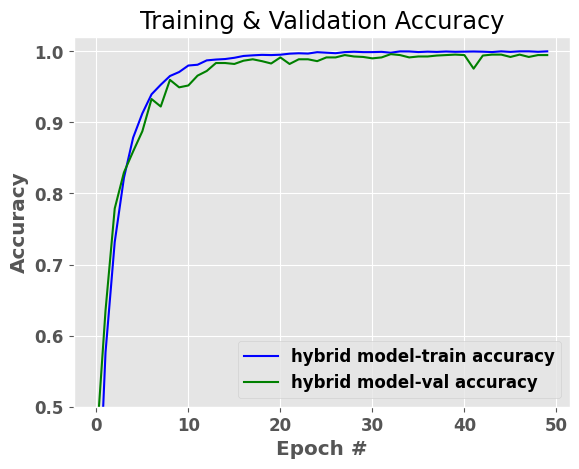

In [ ]:
# plot the training loss and accuracy
plt.style.use("ggplot")
plt.figure()
N = 50
plt.rcParams['font.size'] = '12'
plt.rcParams['font.weight'] = 'bold'


plt.plot(hybrid_model.history["accuracy"], 'b', label="hybrid model-train accuracy")
plt.plot(hybrid_model.history["val_accuracy"], 'g', label="hybrid model-val accuracy")

# plt.plot(vggnet.history["accuracy"], 'pink', label="tuned vgg16-train accuracy")
# plt.plot(vggnet.history["val_accuracy"], 'indigo', label="tuned vgg16-val accuracy")

# plt.plot(base_mobilenet.history["accuracy"], 'cyan', label="tuned MobileNet-train accuracy")
# plt.plot(base_mobilenet.history["val_accuracy"], 'teal', label="tuned MobileNet-val accuracy")


plt.xlabel('font', weight='bold')
plt.ylabel('font', weight='bold')
plt.title('font', weight='bold')
plt.title("Training & Validation Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Accuracy")
plt.legend(loc="lower right")
plt.ylim(0.5,1.02)
plt.savefig('accuracy.png')

# **Loss graph of Combined Model**

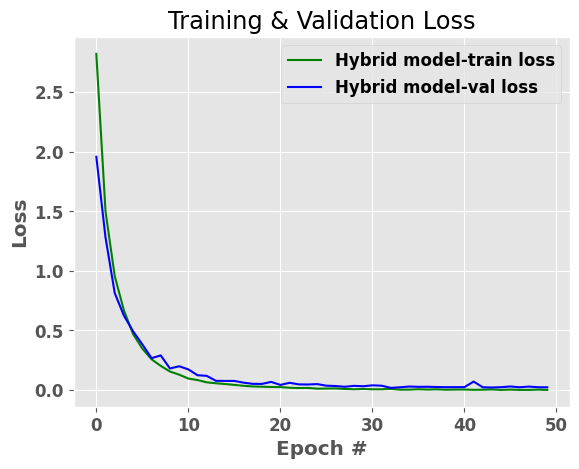

In [ ]:
# plot the training loss and accuracy
plt.style.use("ggplot")
plt.figure()
N = 50
plt.rcParams['font.size'] = '12'
plt.rcParams['font.weight'] = 'bold'


# plt.plot(MN.history["loss"], 'yellow',label="tuned MobileNet-train loss")
# plt.plot(MN.history["val_loss"], 'r', label="tuned MobileNet-val loss")

# plt.plot(VGG.history["loss"], 'brown', label="tuned VGG16-train loss")
# plt.plot(VGG.history["val_loss"], 'orange', label="tuned VGG16-val loss")

plt.plot(hybrid_model.history["loss"], 'green', label="Hybrid model-train loss")
plt.plot(hybrid_model.history["val_loss"], 'blue', label="Hybrid model-val loss")

plt.xlabel('font', weight='bold')
plt.ylabel('font', weight='bold')
plt.title('font', weight='bold')
plt.title("Training & Validation Loss")
plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.legend(loc="upper right")
# plt.ylim(0,0.3)
plt.savefig('loss.png')

# **confusion Matrix**

In [ ]:
class_names = np.array(['ለብስክሌት_ብቻ_የተፈቀደ_ነው',	'የአደባባዩን_ግራ_ይዘህ_ንዳ',	'የአደባባዩን_ቀኝ_ይዘህ_ንዳ',	'በመንገዱ_ላይ_የተፈቀደ_አነስተኛ_ፍጥነት_መጨረሻ',
                        'ፍንዳታ_ለሚያስከትል_ጭነት_የተፈቀደ',	'በግራ_በኩል_ያሽከርክሩ',	'በቀኝ_በኩል_ያሽከርክሩ',	'የጭነት_ተሽከርካሪ_መተላለፊያ',	'አደባባይ_መኖሩን_የሚገልጽ',
                        'የተፈቀደ_አነስተኛ_የፍጥነት_መጠን',	'የመኪና_ማቆሚያን_የሚገልጽ',	'በቀስት_በተጠቆመው_አቅጣጫ_ቀጥል',
                        'ወደ_ግራ_ታጠፍ',	'ተሸከርካሪዎች_ወደ_ተመሳሳይ_መዳረሻ_ለመጓዝ_በሁለቱም_በኩል_ሊያልፉ_ይችላሉ',
                        'ለአንድ_መስመር_ከተቀመጠው_አነስተኛ_ፍጥነት_በላይ_ማሽከርከርን_የሚያስገድድ',
                        'በተለያየ_መስመር_ውስጥ_ተፈጻሚ_እንድሆን_የተቀመጠ_አነስተኛ_የፍጥነት_ወሰን',	'በተለያየ_መስመር_ውስጥ_ተፈጻሚ_እንድሆን_የተቀመ_የፍጥነት_ወሰን',
                        'አልጋ_መኖሩን_የሚገልጽ',	'የእግረኛ_መንገድ',	'አንድ_ማይል_ርቀት_ወደ_ፓርኪንግ_ቦታ',	'የመመገቢያ_ቦታ',	'መሙያ_ጣቢያ',	'የመጀመሪያ_እርዳታን_የሚገልጽ',
                        'ሆስፒታል',	'መረጃ_ቤት',	'መዝናኛ_ወይም_ቡና_ቤት_መኖሩን_የሚገልጽ',	'የመኪና_ማቆሚያ_ቦታ_ከድንገተኛ_ስልክ_ጋር',	'የመኪና_ማቆሚያ_ቦታ',
                        'የጥገና_ቦታ',	'በዚህ_ለተሽከርካሪ_ትራፊክ_መንገድ_የለም',	'ለተሽከርካ_ትራፊክ_መንገድ_የለም',	'የአንድ_መንገድ_ትራፊክ',
                        'የህዝብ_ቴሌፎን',	'የጥገና_ፋሲሊቲ',	'የክፍያ_ዳስ_ምልክት',	'የቱሪስት_እረፍት_ወይም_አካባቢ',	'የጭነት_መኝታ_ምልክት',	'መንቃት_እዚህ_ይጀመራል',
                        'የክብደት_ገደብ',	'ደንበኞች',	'የቅድሚያ_መንገዱ_መጨረሻ',	'የመጨረሻ_ከተማ_ፍጥነት_ገደብ',	'ባዶ_መንገድ_ስጥ',	'ለሚመጡ_ተሽከርካሪዎች_መንገድ_ስጥ',
                        'መንገድ_ስጥ',	'በእንስሳት_የሚነዱ_ጋሪዎች_የሉም',	'ምንም_ሳይክል_የለም',	'መግቢያ_የለም',	'ፈንጂዎች_የሉም',	'ከተጠቆመው_ክብደት_በላይ_ምንም_ዕቃ_የለም',
                        'በእጅ_የሚነዳ_ጋሪ_የለም',	'ጥሩምባ_የለም','ወደ_ግራ_መታጠፍ_የተከለከለ',	'ለተጫነ_ተሽከርካሪ_ማለፍ_የለም',	'ምንም_ተሽከርካሪ_ከሶሎ_ሞተር_ሳይክል_በስተቀር',	'ምንም_ሞተር_ተሽከርካሪ',
                        'ከሁለት_እግር_በላይ_ያላቸው_ተሽከርካሪዎች_መቅደም_የተከለከለ',	'የመኪና_ማቆሚያ_የለም',	'እግረኞች_የሉም',	'ወደ_ቀኝ_መታጠፍ_የተከለከለ',	'ብቸኛ_ሞተር_ሳይክል_የለም',
                        'ማቆም_የለም',	'የሚጎተት_መኪና_የለም',	'የተጎተቱ_ካራቫስ_የለም',	'የከተማ_ክልል',	'ወደ_ዩ_ግራ_መታጠፍ_የለም',	'ወደ_ዩ_ቀኝ_መታጠፍ_የለም',
                        'ምንም_የተሽከርካሪ_እጀታ_ጭነት_በላይ_አልተገለጸም',	'ከኸያ_ቶን_በላይ_ተሽከርካሪ_የተከለከለ',	'ተሽከርካሪ_የለም',	'ከከፍተኛው_ወርድ_በላይ_ምንም_ተሽከርካሪ_አይታይም',
                        'ከተገለጸው_ርዝመት_በላይ_የተከለከለ',	'ከሚታየው_ከፍታ_በላይ_ምንም_ተሽከርካሪ_ማለፍ_አይችልም',	'የመጠበቅ_መጨረሻ',	'አይጠበቅም',	'ቅድሚያ_መንገድ',	'ገደብ_አልቋል',
                        'መስቀለኛ_መንገድ_ከመግባትህ_በፊት_አቁም',	'አቁም',	'ከፍተኛው_ፍጥነት',	'መኪና_አለ',	'ወደግራ_ታጠፍ',	'ወደ_ቀኝ_ታጠፍ',	'ጋሪዎች_ከፊት_አሉ',
                        'የቁልቁል_ማርከሮች',	'መስቀለኛ_መንገድ',	'የአካል_ጉዳተኛ_ሰው',	'ድርብ_ታጠፍ',	'ድርብ_ቁልቁል_ማርከሮች',	'በጥንቃቄ_መንዳት',	'የአስፋልት_መንገድ_መጨረሻ',
                        'የድልድይ_ግድግዳ_መጨረሻ',	'የሁለት_ጋሪ_መንገድ_መጨረሻ',	'በሁለት_የተከፈለ_መንገድ_መጨረሻ',	'የእርሻ_ማሽን_የሚገልጽ_አንድ',	'የእርሻ_ማሽን_የሚገልጽ_ሁለት',
                        'ከፊት_ቀያሽ_አለ',	'መጀመሪያ_ግራ_ከዚያ_ቀጥታ_ታጠፍ',	'መጀመሪያ_ቀኝ_ከዚያ_ቀጥታ_ታጠፍ',	'ከውሃ_እስከ_አስፋልት_መንገድ',	'ለባቡር_ሎኮሞቲቭ_መንገድ_ስጥ',
                        'ጎባጣ_ድልድይ',	'የቤት_እንስሳት',	'ከታጣፊ_መንገድ_ላይ_የሚገነጠል',	'የሚጫወቱ_ልጆች',	'ደረጃ_በእንቅፋት_መሻገር',	'የተጫነ_ደረቅ_ተሽከርካሪ_ከፊት',	'ወንዶች_በስራ_ ላይ',
                        'ጠባብ_ድልድይ',	'በመንገዳው_በሁለት_መንገድ_ተከፈለ',	'ከፍት_ወይም_ዳገታማ_ድልድይ_ከፊት',	'ማረሻ_የእርሻ_ተሽከርካሪ_ከፊት',	'ወንዝ_ዳር',
                        'ተከታታይ_መኪና',	'ድርብ_የባቡር_መስመር',	'ባቡር_በስተግራ_ይሻገራል',	'ባቡር_በስተቀኝ_ይሻገራል',	'ነጠላ_የባቡር_አቋራጭ',	'በመንገዱ_አቋራጭ_የባቡር_ሎኮሞቲቭ',	'የባቡር_መሻገሪያ_T',
                        'የመውደቅ_ወይም_የመውደቅ_ስጋት_መንገድ',	'የመንገድ_ጉብታዎች',	'በሁለቱም_ጎን_መንገዱ_ይጠባል',	'መንገዱ_በቀኝ_ይጠባል',	'መንገድ_ከኪሳራ_ጋር',	'የመንገድ_ስራ_ከፊት',
                        'ክብ_ዙር',	'ትምህርት_ቤት',	'የመንገዱን_ወደ_ግራ_ጥርት_ማዘዋወር',	'የመንገዱን_አቅጣጫ_አጥራ',	'የጎን_መንገድ_ቅርንጫፍ_ግራ',	'የጎን_መንገድ_ቅርንጫፍ_ቀኝ',	'የግራ_ጎን_መንገድ',
                        'ሰያፍ_የቀኝ_ጎን_መንገድ',	'የጎን_መንገድ_ቀኝ',	'ተንሸራታች_መንገድ',	'ሁለት_መንታ_ያለው_መንገድ',	'ቁልቁል_ዳገት_ወደታች',	'ቁልቁል_ዳገት_ወደላይ',	'አመላካች',	'ቲ_ቅርጽ_ያለው_መንገድ',
                        'ቲ_ቅርጽ',	'በግራ_በኩል_የሚዋሃድ_መንገድ_አለ',	'ከፊት_የትራፊክ_ምልክቶች_አሉ',	'ትራም_በመንገድ_ላይ',	'የሁለት_መንገድ_ትራፊክ_በፊት_ማቋረጫ_ላይ',
                        'ባለሁለት_መንገድ_ትራፊክ',	'ያልተስተካከለ_መንገድ',	'የማስጠንቀቂያ_ቀስት_እና_መሰጠት_ውስጥ',	'የማስጠንቀቂያ_ቀስት_ወደፊት_ይቆማል',	'የውሃ_ኮርስ_በመንገድ_ዳር',
                        'የዱር_እንስሳት',	'ነፋስ',	'ዋይ_መገናኛ',	'የዜብራ_መንገድ',	'ዝግዛግ_መንገድ'])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.font_manager as fm
import tensorflow as tf

# === Load Amharic Font ===
font_path = '/usr/share/fonts/truetype/noto/NotoSansEthiopic-Regular.ttf'
# font_path = '/usr/share/fonts/truetype/noto/NotoSans-Regular.ttf'
ethio_font = fm.FontProperties(fname=font_path, size=11)

with tf.device('/gpu:0'):
    # Convert predictions and ground truth
    y_true_classes = np.argmax(y_test, axis=1)
    y_pred_classes = np.argmax(model.predict([X_test, X_test]), axis=1)
    # y_pred_classes = np.argmax(model.predict(X_test), axis=1)

    # # Compute confusion matrix
    # cm = confusion_matrix(y_true_classes, y_pred_classes)

    # # Select a subset of classes to make it readable
    # start_idx, end_idx = 100, 155  # change as needed
    # cm_subset = cm[np.ix_(range(start_idx, end_idx), range(start_idx, end_idx))]
    # class_labels_subset = class_names[start_idx:end_idx]  # your Amharic class names
    # # === Replace underscores with spaces ===
    # class_labels_subset = [name.replace('_', ' ') for name in class_labels_subset]

    # # Plot
    # plt.figure(figsize=(20, 16))
    # ax = sns.heatmap(cm_subset, annot=True, fmt="d", cmap="Blues",
    #                  xticklabels=class_labels_subset,
    #                  yticklabels=class_labels_subset,
    #                  cbar=True,annot_kws={"size": 14})

    # # Set Amharic labels for axes and title
    # ax.set_xlabel("Predicted vlaue")  # Predicted Label
    # ax.set_ylabel("True Value")  # True Label
    # ax.set_title("Confusion Matrix for class 100 - 55 ")

    # # Rotate x-ticks for readability
    # plt.xticks(rotation=45, ha="right", fontproperties=ethio_font)
    # plt.yticks(fontproperties=ethio_font)
    # plt.tight_layout()
    # plt.show()

69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step


In [ ]:
#classification report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
# from sklearn.utils.multi_label import unique_labels
from sklearn.utils.multiclass import unique_labels
plt.rcParams['font.size'] = '13'
# Get predicted values
y_pred = model.predict([X_test, X_test])  # outputs probabilities of each classes
# y_pred = model.predict(X_test)  # outputs probabilities of each classes
# Create empty numpy array to match length of training data
y_pred_array = np.zeros(X_test.shape[0])
plt.rcParams['font.size'] = '13'
# Find class with highest probability
for i in range(0, y_pred.shape[0]):
    label_predict = np.argmax(y_pred[i]) # column with max probability
    y_pred_array[i] = label_predict

# convert to integers
y_pred_array = y_pred_array.astype(int)

# Convert y_test to 1d numpy array
y_test_array = np.zeros(X_test.shape[0])

# Find class with 1
for i in range(0, y_test.shape[0]):
    label_predict = np.argmax(y_test[i])
    y_test_array[i] = label_predict

y_test_array = y_test_array.astype(int)
# # print(confusion_matrix(y_test_array, y_pred_array))
# target_names = ['ለብስክሌት_ብቻ_የተፈቀደ_ነው',	'የአደባባዩን_ግራ_ይዘህ_ንዳ',	'የአደባባዩን_ቀኝ_ይዘህ_ንዳ',	'በመንገዱ_ላይ_የተፈቀደ_አነስተኛ_ፍጥነት_መጨረሻ',
#                         'ፍንዳታ_ለሚያስከትል_ጭነት_የተፈቀደ',	'በግራ_በኩል_ያሽከርክሩ',	'በቀኝ_በኩል_ያሽከርክሩ',	'የጭነት_ተሽከርካሪ_መተላለፊያ',	'አደባባይ_መኖሩን_የሚገልጽ',
#                         'የተፈቀደ_አነስተኛ_የፍጥነት_መጠን',	'የመኪና_ማቆሚያን_የሚገልጽ',	'በቀስት_በተጠቆመው_አቅጣጫ_ቀጥል',
#                         'ወደ_ግራ_ታጠፍ',	'ተሸከርካሪዎች_ወደ_ተመሳሳይ_መዳረሻ_ለመጓዝ_በሁለቱም_በኩል_ሊያልፉ_ይችላሉ',
#                         'ለአንድ_መስመር_ከተቀመጠው_አነስተኛ_ፍጥነት_በላይ_ማሽከርከርን_የሚያስገድድ',
#                         'በተለያየ_መስመር_ውስጥ_ተፈጻሚ_እንድሆን_የተቀመጠ_አነስተኛ_የፍጥነት_ወሰን',	'በተለያየ_መስመር_ውስጥ_ተፈጻሚ_እንድሆን_የተቀመ_የፍጥነት_ወሰን',
#                         'አልጋ_መኖሩን_የሚገልጽ',	'የእግረኛ_መንገድ',	'አንድ_ማይል_ርቀት_ወደ_ፓርኪንግ_ቦታ',	'የመመገቢያ_ቦታ',	'መሙያ_ጣቢያ',	'የመጀመሪያ_እርዳታን_የሚገልጽ',
#                         'ሆስፒታል',	'መረጃ_ቤት',	'መዝናኛ_ወይም_ቡና_ቤት_መኖሩን_የሚገልጽ',	'የመኪና_ማቆሚያ_ቦታ_ከድንገተኛ_ስልክ_ጋር',	'የመኪና_ማቆሚያ_ቦታ',
#                         'የጥገና_ቦታ',	'በዚህ_ለተሽከርካሪ_ትራፊክ_መንገድ_የለም',	'ለተሽከርካ_ትራፊክ_መንገድ_የለም',	'የአንድ_መንገድ_ትራፊክ',
#                         'የህዝብ_ቴሌፎን',	'የጥገና_ፋሲሊቲ',	'የክፍያ_ዳስ_ምልክት',	'የቱሪስት_እረፍት_ወይም_አካባቢ',	'የጭነት_መኝታ_ምልክት',	'መንቃት_እዚህ_ይጀመራል',
#                         'የክብደት_ገደብ',	'ደንበኞች',	'የቅድሚያ_መንገዱ_መጨረሻ',	'የመጨረሻ_ከተማ_ፍጥነት_ገደብ',	'ባዶ_መንገድ_ስጥ',	'ለሚመጡ_ተሽከርካሪዎች_መንገድ_ስጥ',
#                         'መንገድ_ስጥ',	'በእንስሳት_የሚነዱ_ጋሪዎች_የሉም',	'ምንም_ሳይክል_የለም',	'መግቢያ_የለም',	'ፈንጂዎች_የሉም',	'ከተጠቆመው_ክብደት_በላይ_ምንም_ዕቃ_የለም',
#                         'በእጅ_የሚነዳ_ጋሪ_የለም',	'ጥሩምባ_የለም','ወደ_ግራ_መታጠፍ_የተከለከለ',	'ለተጫነ_ተሽከርካሪ_ማለፍ_የለም',	'ምንም_ተሽከርካሪ_ከሶሎ_ሞተር_ሳይክል_በስተቀር',	'ምንም_ሞተር_ተሽከርካሪ',
#                         'ከሁለት_እግር_በላይ_ያላቸው_ተሽከርካሪዎች_መቅደም_የተከለከለ',	'የመኪና_ማቆሚያ_የለም',	'እግረኞች_የሉም',	'ወደ_ቀኝ_መታጠፍ_የተከለከለ',	'ብቸኛ_ሞተር_ሳይክል_የለም',
#                         'ማቆም_የለም',	'የሚጎተት_መኪና_የለም',	'የተጎተቱ_ካራቫስ_የለም',	'የከተማ_ክልል',	'ወደ_ዩ_ግራ_መታጠፍ_የለም',	'ወደ_ዩ_ቀኝ_መታጠፍ_የለም',
#                         'ምንም_የተሽከርካሪ_እጀታ_ጭነት_በላይ_አልተገለጸም',	'ከኸያ_ቶን_በላይ_ተሽከርካሪ_የተከለከለ',	'ተሽከርካሪ_የለም',	'ከከፍተኛው_ወርድ_በላይ_ምንም_ተሽከርካሪ_አይታይም',
#                         'ከተገለጸው_ርዝመት_በላይ_የተከለከለ',	'ከሚታየው_ከፍታ_በላይ_ምንም_ተሽከርካሪ_ማለፍ_አይችልም',	'የመጠበቅ_መጨረሻ',	'አይጠበቅም',	'ቅድሚያ_መንገድ',	'ገደብ_አልቋል',
#                         'መስቀለኛ_መንገድ_ከመግባትህ_በፊት_አቁም',	'አቁም',	'ከፍተኛው_ፍጥነት',	'መኪና_አለ',	'ወደግራ_ታጠፍ',	'ወደ_ቀኝ_ታጠፍ',	'ጋሪዎች_ከፊት_አሉ',
#                         'የቁልቁል_ማርከሮች',	'መስቀለኛ_መንገድ',	'የአካል_ጉዳተኛ_ሰው',	'ድርብ_ታጠፍ',	'ድርብ_ቁልቁል_ማርከሮች',	'በጥንቃቄ_መንዳት',	'የአስፋልት_መንገድ_መጨረሻ',
#                         'የድልድይ_ግድግዳ_መጨረሻ',	'የሁለት_ጋሪ_መንገድ_መጨረሻ',	'በሁለት_የተከፈለ_መንገድ_መጨረሻ',	'የእርሻ_ማሽን_የሚገልጽ_አንድ',	'የእርሻ_ማሽን_የሚገልጽ_ሁለት',
#                         'ከፊት_ቀያሽ_አለ',	'መጀመሪያ_ግራ_ከዚያ_ቀጥታ_ታጠፍ',	'መጀመሪያ_ቀኝ_ከዚያ_ቀጥታ_ታጠፍ',	'ከውሃ_እስከ_አስፋልት_መንገድ',	'ለባቡር_ሎኮሞቲቭ_መንገድ_ስጥ',
#                         'ጎባጣ_ድልድይ',	'የቤት_እንስሳት',	'ከታጣፊ_መንገድ_ላይ_የሚገነጠል',	'የሚጫወቱ_ልጆች',	'ደረጃ_በእንቅፋት_መሻገር',	'የተጫነ_ደረቅ_ተሽከርካሪ_ከፊት',	'ወንዶች_በስራ_ ላይ',
#                         'ጠባብ_ድልድይ',	'በመንገዳው_በሁለት_መንገድ_ተከፈለ',	'ከፍት_ወይም_ዳገታማ_ድልድይ_ከፊት',	'ማረሻ_የእርሻ_ተሽከርካሪ_ከፊት',	'ወንዝ_ዳር',
#                         'ተከታታይ_መኪና',	'ድርብ_የባቡር_መስመር',	'ባቡር_በስተግራ_ይሻገራል',	'ባቡር_በስተቀኝ_ይሻገራል',	'ነጠላ_የባቡር_አቋራጭ',	'በመንገዱ_አቋራጭ_የባቡር_ሎኮሞቲቭ',	'የባቡር_መሻገሪያ_T',
#                         'የመውደቅ_ወይም_የመውደቅ_ስጋት_መንገድ',	'የመንገድ_ጉብታዎች',	'በሁለቱም_ጎን_መንገዱ_ይጠባል',	'መንገዱ_በቀኝ_ይጠባል',	'መንገድ_ከኪሳራ_ጋር',	'የመንገድ_ስራ_ከፊት',
#                         'ክብ_ዙር',	'ትምህርት_ቤት',	'የመንገዱን_ወደ_ግራ_ጥርት_ማዘዋወር',	'የመንገዱን_አቅጣጫ_አጥራ',	'የጎን_መንገድ_ቅርንጫፍ_ግራ',	'የጎን_መንገድ_ቅርንጫፍ_ቀኝ',	'የግራ_ጎን_መንገድ',
#                         'ሰያፍ_የቀኝ_ጎን_መንገድ',	'የጎን_መንገድ_ቀኝ',	'ተንሸራታች_መንገድ',	'ሁለት_መንታ_ያለው_መንገድ',	'ቁልቁል_ዳገት_ወደታች',	'ቁልቁል_ዳገት_ወደላይ',	'አመላካች',	'ቲ_ቅርጽ_ያለው_መንገድ',
#                         'ቲ_ቅርጽ',	'በግራ_በኩል_የሚዋሃድ_መንገድ_አለ',	'ከፊት_የትራፊክ_ምልክቶች_አሉ',	'ትራም_በመንገድ_ላይ',	'የሁለት_መንገድ_ትራፊክ_በፊት_ማቋረጫ_ላይ',
#                         'ባለሁለት_መንገድ_ትራፊክ',	'ያልተስተካከለ_መንገድ',	'የማስጠንቀቂያ_ቀስት_እና_መሰጠት_ውስጥ',	'የማስጠንቀቂያ_ቀስት_ወደፊት_ይቆማል',	'የውሃ_ኮርስ_በመንገድ_ዳር',
#                         'የዱር_እንስሳት',	'ነፋስ',	'ዋይ_መገናኛ',	'የዜብራ_መንገድ',	'ዝግዛግ_መንገድ']
# # print(classification_report(y_test_array, y_pred_array, labels=[0,1,2,3]))
# print(classification_report(y_test_array, y_pred_array, target_names=target_names))

69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step


In [ ]:
import numpy as np
y_gt = y_test_array
y_pr = y_pred_array
from sklearn.metrics import f1_score, precision_score,recall_score
p_macro = precision_score(y_gt, y_pr, average="macro")
p_micro = precision_score(y_gt, y_pr, average="micro")
p_weighted = precision_score(y_gt, y_pr, average="weighted")
r_macro = recall_score(y_gt, y_pr, average="macro")
r_micro = recall_score(y_gt, y_pr, average="micro")
r_weighted = recall_score(y_gt, y_pr, average="weighted")
fl_macro = f1_score(y_gt, y_pr, average="macro")
f1_micro = f1_score(y_gt, y_pr, average="micro")
f1_weighted = f1_score(y_gt, y_pr, average="weighted")
print('============ Precision Score ============')
print("P_macro:  {:.2f}".format(p_macro *100))
print("P_micro:  {:.2f}".format(p_micro *100))
print("P_weighted:  {:.2f}".format(p_weighted *100))
print('============ Recall Score ============')
print("R_macro:  {:.2f}".format(r_macro *100))
print("R_micro:  {:.2f}".format(r_micro *100))
print("R_weighted:  {:.2f}".format(r_weighted *100))
print('============ F1 Score ============')
print("F1_macro:  {:.2f}".format(fl_macro *100))
print("F1_micro:  {:.2f}".format(f1_micro*100))
print("F1_weighted:  {:.2f}".format(f1_weighted*100))

============ Precision Score ============
P_macro:  97.97
P_micro:  98.73
P_weighted:  98.18
============ Recall Score ============
R_macro:  98.68
R_micro:  98.73
R_weighted:  98.73
============ F1 Score ============
F1_macro:  98.19
F1_micro:  98.73
F1_weighted:  98.35


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# **Failure-case panel**

In [ ]:
# Get model predictions
pred_probs = model.predict([X_test,X_test])  # shape: (num_samples, num_classes)
pred_labels = np.argmax(pred_probs, axis=1)
confidences = np.max(pred_probs, axis=1)  # confidence of predicted class

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [ ]:
y_test_labels = np.argmax(y_test, axis=1)
y_test_labels = np.argmax(y_test, axis=1) if len(y_test.shape) > 1 else y_test
# Find misclassified images
misclassified_idx = np.where(pred_labels != y_test_labels)[0]
# Optional: sort by confidence (highest confidence mistakes first)
misclassified_idx = misclassified_idx[np.argsort(-confidences[misclassified_idx])]

In [ ]:
top_n = len(misclassified_idx)  # for a 2x3 panel
top_misclassified = misclassified_idx[:top_n]

In [ ]:
class_names = ['ለብስክሌት_ብቻ_የተፈቀደ_ነው',	'የአደባባዩን_ግራ_ይዘህ_ንዳ',	'የአደባባዩን_ቀኝ_ይዘህ_ንዳ',	'በመንገዱ_ላይ_የተፈቀደ_አነስተኛ_ፍጥነት_መጨረሻ',
                        'ፍንዳታ_ለሚያስከትል_ጭነት_የተፈቀደ',	'በግራ_በኩል_ያሽከርክሩ',	'በቀኝ_በኩል_ያሽከርክሩ',	'የጭነት_ተሽከርካሪ_መተላለፊያ',	'አደባባይ_መኖሩን_የሚገልጽ',
                        'የተፈቀደ_አነስተኛ_የፍጥነት_መጠን',	'የመኪና_ማቆሚያን_የሚገልጽ',	'በቀስት_በተጠቆመው_አቅጣጫ_ቀጥል',
                        'ወደ_ግራ_ታጠፍ',	'ተሸከርካሪዎች_ወደ_ተመሳሳይ_መዳረሻ_ለመጓዝ_በሁለቱም_በኩል_ሊያልፉ_ይችላሉ',
                        'ለአንድ_መስመር_ከተቀመጠው_አነስተኛ_ፍጥነት_በላይ_ማሽከርከርን_የሚያስገድድ',
                        'በተለያየ_መስመር_ውስጥ_ተፈጻሚ_እንድሆን_የተቀመጠ_አነስተኛ_የፍጥነት_ወሰን',	'በተለያየ_መስመር_ውስጥ_ተፈጻሚ_እንድሆን_የተቀመ_የፍጥነት_ወሰን',
                        'አልጋ_መኖሩን_የሚገልጽ',	'የእግረኛ_መንገድ',	'አንድ_ማይል_ርቀት_ወደ_ፓርኪንግ_ቦታ',	'የመመገቢያ_ቦታ',	'መሙያ_ጣቢያ',	'የመጀመሪያ_እርዳታን_የሚገልጽ',
                        'ሆስፒታል',	'መረጃ_ቤት',	'መዝናኛ_ወይም_ቡና_ቤት_መኖሩን_የሚገልጽ',	'የመኪና_ማቆሚያ_ቦታ_ከድንገተኛ_ስልክ_ጋር',	'የመኪና_ማቆሚያ_ቦታ',
                        'የጥገና_ቦታ',	'በዚህ_ለተሽከርካሪ_ትራፊክ_መንገድ_የለም',	'ለተሽከርካ_ትራፊክ_መንገድ_የለም',	'የአንድ_መንገድ_ትራፊክ',
                        'የህዝብ_ቴሌፎን',	'የጥገና_ፋሲሊቲ',	'የክፍያ_ዳስ_ምልክት',	'የቱሪስት_እረፍት_ወይም_አካባቢ',	'የጭነት_መኝታ_ምልክት',	'መንቃት_እዚህ_ይጀመራል',
                        'የክብደት_ገደብ',	'ደንበኞች',	'የቅድሚያ_መንገዱ_መጨረሻ',	'የመጨረሻ_ከተማ_ፍጥነት_ገደብ',	'ባዶ_መንገድ_ስጥ',	'ለሚመጡ_ተሽከርካሪዎች_መንገድ_ስጥ',
                        'መንገድ_ስጥ',	'በእንስሳት_የሚነዱ_ጋሪዎች_የሉም',	'ምንም_ሳይክል_የለም',	'መግቢያ_የለም',	'ፈንጂዎች_የሉም',	'ከተጠቆመው_ክብደት_በላይ_ምንም_ዕቃ_የለም',
                        'በእጅ_የሚነዳ_ጋሪ_የለም',	'ጥሩምባ_የለም','ወደ_ግራ_መታጠፍ_የተከለከለ',	'ለተጫነ_ተሽከርካሪ_ማለፍ_የለም',	'ምንም_ተሽከርካሪ_ከሶሎ_ሞተር_ሳይክል_በስተቀር',	'ምንም_ሞተር_ተሽከርካሪ',
                        'ከሁለት_እግር_በላይ_ያላቸው_ተሽከርካሪዎች_መቅደም_የተከለከለ',	'የመኪና_ማቆሚያ_የለም',	'እግረኞች_የሉም',	'ወደ_ቀኝ_መታጠፍ_የተከለከለ',	'ብቸኛ_ሞተር_ሳይክል_የለም',
                        'ማቆም_የለም',	'የሚጎተት_መኪና_የለም',	'የተጎተቱ_ካራቫስ_የለም',	'የከተማ_ክልል',	'ወደ_ዩ_ግራ_መታጠፍ_የለም',	'ወደ_ዩ_ቀኝ_መታጠፍ_የለም',
                        'ምንም_የተሽከርካሪ_እጀታ_ጭነት_በላይ_አልተገለጸም',	'ከኸያ_ቶን_በላይ_ተሽከርካሪ_የተከለከለ',	'ተሽከርካሪ_የለም',	'ከከፍተኛው_ወርድ_በላይ_ምንም_ተሽከርካሪ_አይታይም',
                        'ከተገለጸው_ርዝመት_በላይ_የተከለከለ',	'ከሚታየው_ከፍታ_በላይ_ምንም_ተሽከርካሪ_ማለፍ_አይችልም',	'የመጠበቅ_መጨረሻ',	'አይጠበቅም',	'ቅድሚያ_መንገድ',	'ገደብ_አልቋል',
                        'መስቀለኛ_መንገድ_ከመግባትህ_በፊት_አቁም',	'አቁም',	'ከፍተኛው_ፍጥነት',	'መኪና_አለ',	'ወደግራ_ታጠፍ',	'ወደ_ቀኝ_ታጠፍ',	'ጋሪዎች_ከፊት_አሉ',
                        'የቁልቁል_ማርከሮች',	'መስቀለኛ_መንገድ',	'የአካል_ጉዳተኛ_ሰው',	'ድርብ_ታጠፍ',	'ድርብ_ቁልቁል_ማርከሮች',	'በጥንቃቄ_መንዳት',	'የአስፋልት_መንገድ_መጨረሻ',
                        'የድልድይ_ግድግዳ_መጨረሻ',	'የሁለት_ጋሪ_መንገድ_መጨረሻ',	'በሁለት_የተከፈለ_መንገድ_መጨረሻ',	'የእርሻ_ማሽን_የሚገልጽ_አንድ',	'የእርሻ_ማሽን_የሚገልጽ_ሁለት',
                        'ከፊት_ቀያሽ_አለ',	'መጀመሪያ_ግራ_ከዚያ_ቀጥታ_ታጠፍ',	'መጀመሪያ_ቀኝ_ከዚያ_ቀጥታ_ታጠፍ',	'ከውሃ_እስከ_አስፋልት_መንገድ',	'ለባቡር_ሎኮሞቲቭ_መንገድ_ስጥ',
                        'ጎባጣ_ድልድይ',	'የቤት_እንስሳት',	'ከታጣፊ_መንገድ_ላይ_የሚገነጠል',	'የሚጫወቱ_ልጆች',	'ደረጃ_በእንቅፋት_መሻገር',	'የተጫነ_ደረቅ_ተሽከርካሪ_ከፊት',	'ወንዶች_በስራ_ ላይ',
                        'ጠባብ_ድልድይ',	'በመንገዳው_በሁለት_መንገድ_ተከፈለ',	'ከፍት_ወይም_ዳገታማ_ድልድይ_ከፊት',	'ማረሻ_የእርሻ_ተሽከርካሪ_ከፊት',	'ወንዝ_ዳር',
                        'ተከታታይ_መኪና',	'ድርብ_የባቡር_መስመር',	'ባቡር_በስተግራ_ይሻገራል',	'ባቡር_በስተቀኝ_ይሻገራል',	'ነጠላ_የባቡር_አቋራጭ',	'በመንገዱ_አቋራጭ_የባቡር_ሎኮሞቲቭ',	'የባቡር_መሻገሪያ_T',
                        'የመውደቅ_ወይም_የመውደቅ_ስጋት_መንገድ',	'የመንገድ_ጉብታዎች',	'በሁለቱም_ጎን_መንገዱ_ይጠባል',	'መንገዱ_በቀኝ_ይጠባል',	'መንገድ_ከኪሳራ_ጋር',	'የመንገድ_ስራ_ከፊት',
                        'ክብ_ዙር',	'ትምህርት_ቤት',	'የመንገዱን_ወደ_ግራ_ጥርት_ማዘዋወር',	'የመንገዱን_አቅጣጫ_አጥራ',	'የጎን_መንገድ_ቅርንጫፍ_ግራ',	'የጎን_መንገድ_ቅርንጫፍ_ቀኝ',	'የግራ_ጎን_መንገድ',
                        'ሰያፍ_የቀኝ_ጎን_መንገድ',	'የጎን_መንገድ_ቀኝ',	'ተንሸራታች_መንገድ',	'ሁለት_መንታ_ያለው_መንገድ',	'ቁልቁል_ዳገት_ወደታች',	'ቁልቁል_ዳገት_ወደላይ',	'አመላካች',	'ቲ_ቅርጽ_ያለው_መንገድ',
                        'ቲ_ቅርጽ',	'በግራ_በኩል_የሚዋሃድ_መንገድ_አለ',	'ከፊት_የትራፊክ_ምልክቶች_አሉ',	'ትራም_በመንገድ_ላይ',	'የሁለት_መንገድ_ትራፊክ_በፊት_ማቋረጫ_ላይ',
                        'ባለሁለት_መንገድ_ትራፊክ',	'ያልተስተካከለ_መንገድ',	'የማስጠንቀቂያ_ቀስት_እና_መሰጠት_ውስጥ',	'የማስጠንቀቂያ_ቀስት_ወደፊት_ይቆማል',	'የውሃ_ኮርስ_በመንገድ_ዳር',
                        'የዱር_እንስሳት',	'ነፋስ',	'ዋይ_መገናኛ',	'የዜብራ_መንገድ',	'ዝግዛግ_መንገድ'] # include all traffic signs

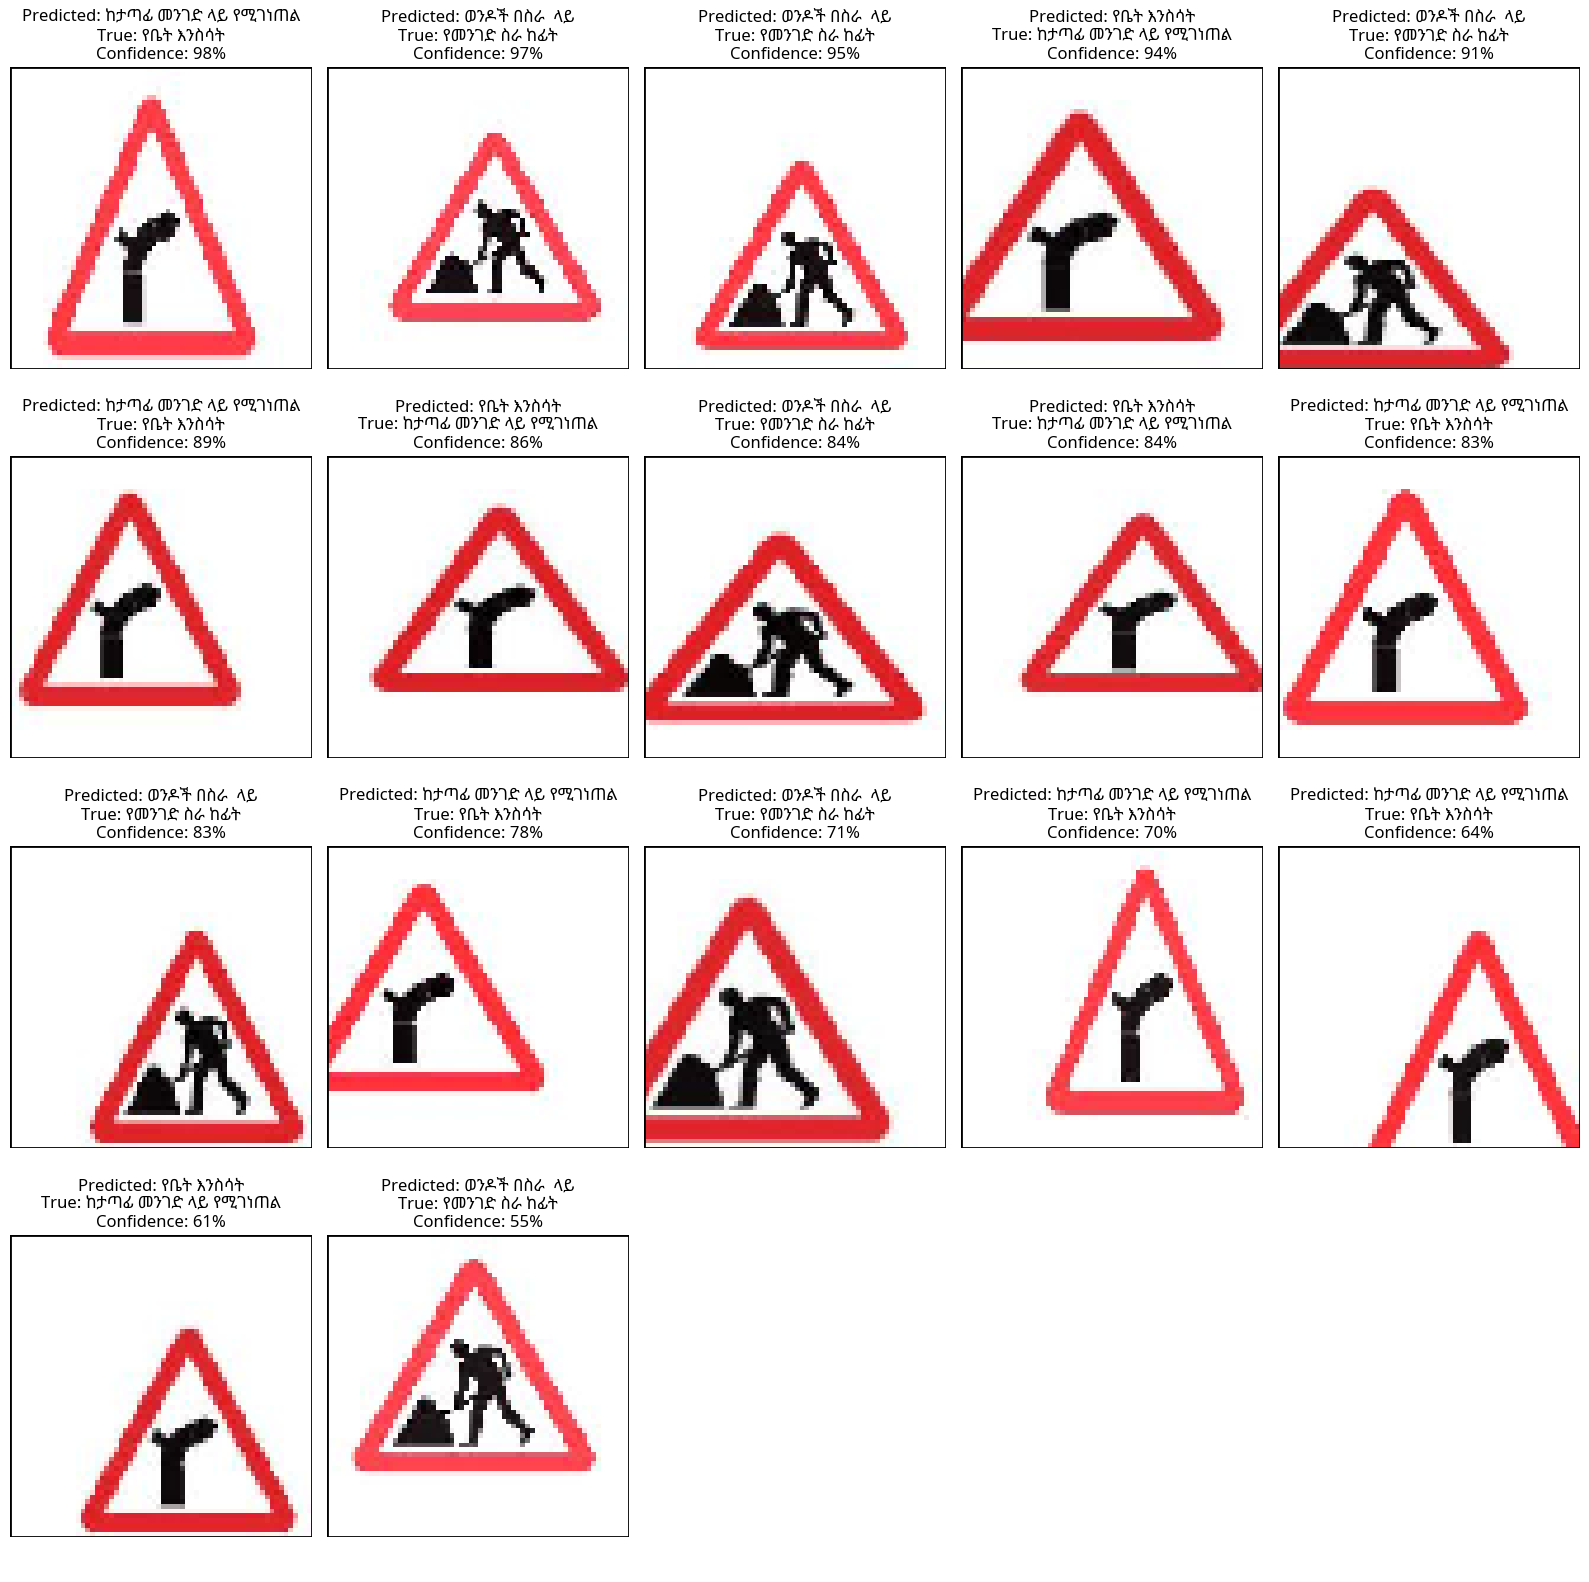

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as patches

# === Register both fonts manually ===
amharic_font_path = '/usr/share/fonts/truetype/noto/NotoSansEthiopic-Regular.ttf'
latin_font_path = '/usr/share/fonts/truetype/noto/NotoSans-Regular.ttf'

fm.fontManager.addfont(amharic_font_path)
fm.fontManager.addfont(latin_font_path)

# === Now set fallback ===
plt.rcParams['font.family'] = ['Noto Sans Ethiopic', 'Noto Sans', 'DejaVu Sans']

# === plotting code ===
fig, axes = plt.subplots(4, 5, figsize=(16, 16))
for i, ax in enumerate(axes.flat):
    if i >= len(top_misclassified):  # avoid out-of-range index
        ax.axis('off')  # hide extra axes
        continue

    idx = top_misclassified[i]
    img = X_test[idx]

    # Display image
    ax.imshow(img)

        # Set background color for this subplot only
    ax.set_facecolor('#d3d3d3')

    # Add a full border around the image (all sides)
    rect = patches.Rectangle(
        (0, 0), 1, 1,                     # full axes coordinates
        transform=ax.transAxes,
        linewidth=2,                       # border thickness
        edgecolor='black',                   # border color
        facecolor='none'                   # no fill
    )
    ax.add_patch(rect)

    title_text = (
        f"Predicted: {class_names[pred_labels[idx]].replace('_', ' ')}\n"
        f"True: {class_names[y_test_labels[idx]].replace('_', ' ')}\n"
        f"Confidence: {confidences[idx]*100:.0f}%"
    )
    ax.set_title(title_text, fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()



# **confidence plot**

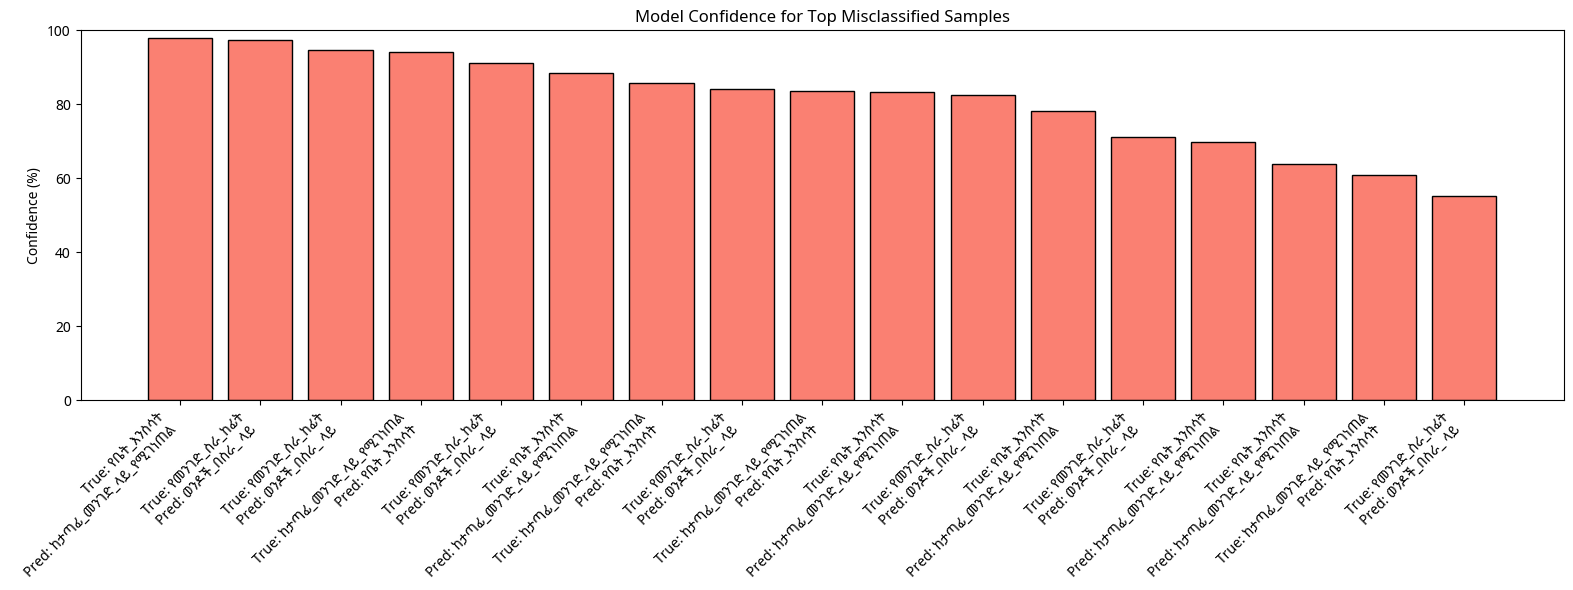

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

top_idx = top_misclassified[:40]  # select top 10 misclassified samples

plt.figure(figsize=(16, 6))

for i, idx in enumerate(top_idx):
    plt.bar(
        i,
        confidences[idx]*100,   # convert to %
        color='salmon',
        edgecolor='black'
    )

plt.xticks(
    range(len(top_idx)),
    [f"True: {class_names[y_test_labels[idx]]}\nPred: {class_names[pred_labels[idx]]}" for idx in top_idx],
    rotation=45,
    ha='right'
)
plt.ylabel("Confidence (%)")
plt.title("Model Confidence for Top Misclassified Samples")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [ ]:
# --- Define Classification Models for Grad-CAM ---

# Get the number of classes from the y_train shape
num_classes = y_train.shape[1]

# Create a classification head for MobileNet for Grad-CAM
x_mob = base_model_mobilenet.output
x_mob = GlobalAveragePooling2D()(x_mob)
x_mob = Dense(num_classes, activation='softmax')(x_mob)
mobilenet_classification_model = Model(inputs=base_model_mobilenet.input, outputs=x_mob, name='mobilenet_classifier')

# Create a classification head for VGG16 for Grad-CAM
x_vgg = base_model_vgg16.output
x_vgg = GlobalAveragePooling2D()(x_vgg)
x_vgg = Dense(num_classes, activation='softmax')(x_vgg)
vgg_classification_model = Model(inputs=base_model_vgg16.input, outputs=x_vgg, name='vgg16_classifier')

print("Classification models for Grad-CAM defined.")

Classification models for Grad-CAM defined.


In [ ]:
class_labels = train.drop(['image', 'tags'], axis=1).columns.tolist()

# **GRAD-CAM**

**Mobilenet feature extractor**

In [ ]:
mobilenet_base = MobileNet(
    weights="imagenet",
    include_top=False,
    input_shape=(64, 64, 3)
)

mobilenet_conv_layer = "conv_pw_5_relu"

mobilenet_model = Model(
    inputs=base_model_mobilenet.input,
    outputs=[
        mobilenet_base.get_layer(mobilenet_conv_layer).output,
        GlobalAveragePooling2D()(mobilenet_base.output)
    ]
)

/tmp/ipykernel_577/4170794532.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet_base = MobileNet(


**VGG16 featur extractor**

In [ ]:
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(64, 64, 3)
)

vgg_conv_layer = "block3_conv3"

vgg_model = Model(
    inputs=base_model_vgg16.input,
    outputs=[
        vgg_base.get_layer(vgg_conv_layer).output,
        GlobalAveragePooling2D()(vgg_base.output)
    ]
)

**Mobile Net classifier**

In [ ]:
mobilenet_base = MobileNet(
    weights="imagenet",
    include_top=False,
    input_shape=(64, 64, 3)
)

x = mobilenet_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(156, activation="softmax")(x)

mobilenet_classifier = Model(
    inputs=mobilenet_base.input,
    outputs=x
)

/tmp/ipykernel_16314/2573502694.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet_base = MobileNet(


**VGG16 classifier (GRad-cam)**

In [ ]:
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(64, 64, 3)
)

x = vgg_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(156, activation="softmax")(x)

vgg_classifier = Model(
    inputs=vgg_base.input,
    outputs=x
)

**GRAD-CAM  functions**

In [ ]:
def make_gradcam_heatmap(inputs, model, last_conv_layer_name):

    last_conv_layer = model.get_layer(last_conv_layer_name)

    grad_model = Model(
        inputs=model.inputs,
        outputs=[last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(inputs, training=False)

        class_idx = tf.argmax(predictions[0])
        class_channel = predictions[:, class_idx]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), predictions.numpy()

**Overlay function**

In [ ]:
def overlay_heatmap(heatmap, image, alpha=0.4):

    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    image = (image * 255).astype("uint8")

    return cv2.addWeighted(image, 1-alpha, heatmap, alpha, 0)

**Visualization function**

In [ ]:
def run_gradcam(image, true_label, class_names):

    img_array = np.expand_dims(image, axis=0)

    # Hybrid requires TWO inputs
    inputs = [img_array, img_array]

    # 🔷 MobileNet branch
    heatmap_mob, pred = make_gradcam_heatmap(
        inputs,
        model,
        "conv_pw_5_relu"
    )

    # 🔷 VGG branch
    heatmap_vgg, pred = make_gradcam_heatmap(
        inputs,
        model,
        "block3_conv3"
    )

    pred_idx = np.argmax(pred)
    pred_class = class_names[pred_idx]
    confidence = np.max(pred) * 100

    true_idx = np.argmax(true_label)
    true_class = class_names[true_idx]

    mob_img = overlay_heatmap(heatmap_mob, image)
    vgg_img = overlay_heatmap(heatmap_vgg, image)

    # Plot
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(mob_img)
    plt.title("MobileNet Attention")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(vgg_img)
    plt.title("VGG16 Attention")
    plt.axis("off")

    plt.suptitle(f"True: {true_class} | Pred: {pred_class} ({confidence:.2f}%)")

    plt.tight_layout()
    plt.show()

In [ ]:
import cv2
def run_gradcam(image, true_label, class_names):

    img_array = np.expand_dims(image, axis=0)

    # Hybrid input (two branches)
    inputs = [img_array, img_array]

    # Grad-CAM for both branches
    heatmap_mob, pred = make_gradcam_heatmap(
        inputs,
        model,
        "conv_pw_5_relu"
    )

    heatmap_vgg, pred = make_gradcam_heatmap(
        inputs,
        model,
        "block3_conv3"
    )

    # Predictions
    pred_idx = np.argmax(pred)
    pred_class = class_names[pred_idx]
    confidence = np.max(pred) * 100

    true_idx = np.argmax(true_label)
    true_class = class_names[true_idx]

    # Overlay images
    mob_img = overlay_heatmap(heatmap_mob, image)
    vgg_img = overlay_heatmap(heatmap_vgg, image)

    # Plot
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(mob_img)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(vgg_img)
    plt.axis("off")

    # Clean, publication-style text (separate lines)
    plt.suptitle(
        f"True: {true_class}\nPredicted: {pred_class} ({confidence:.2f}%)",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

**run on test images**

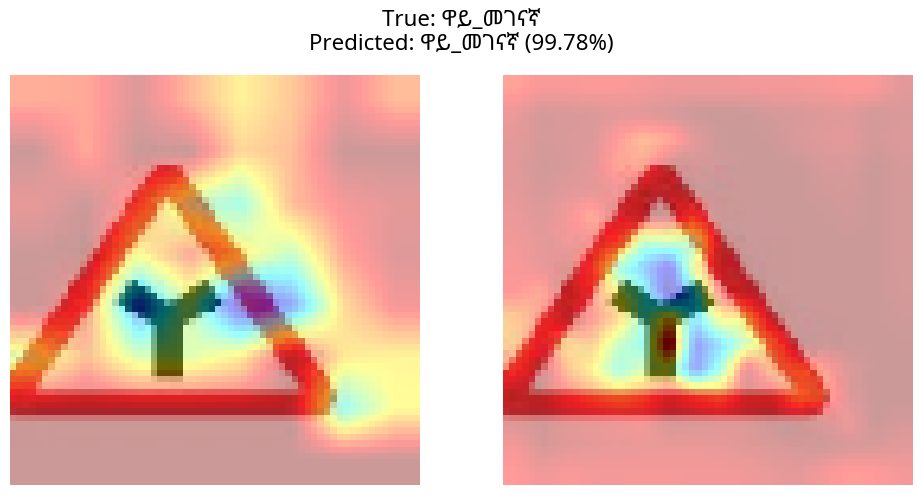

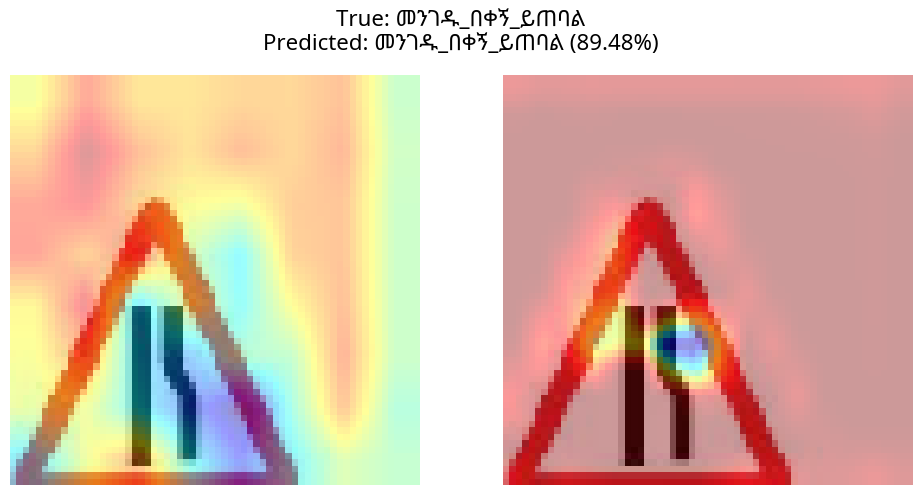

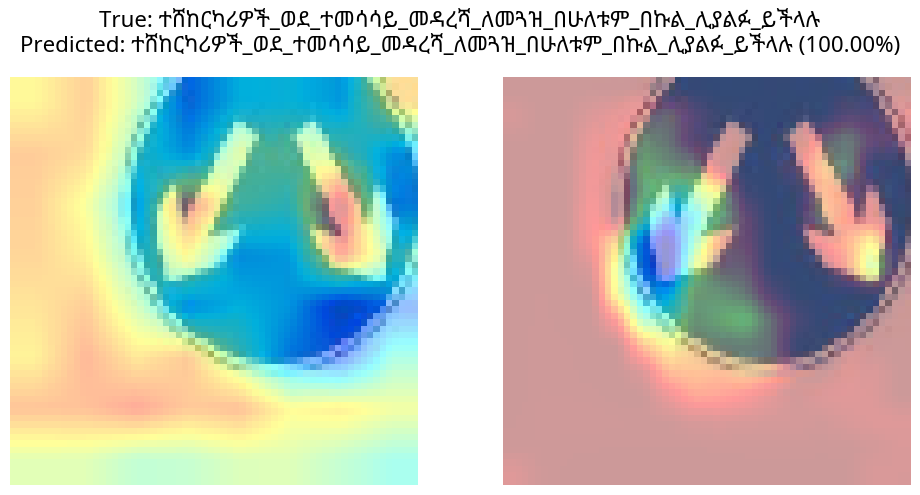

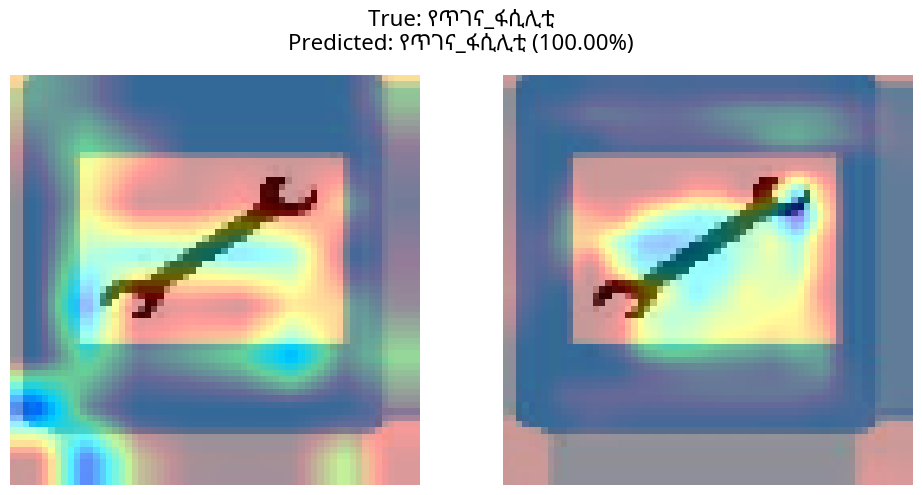

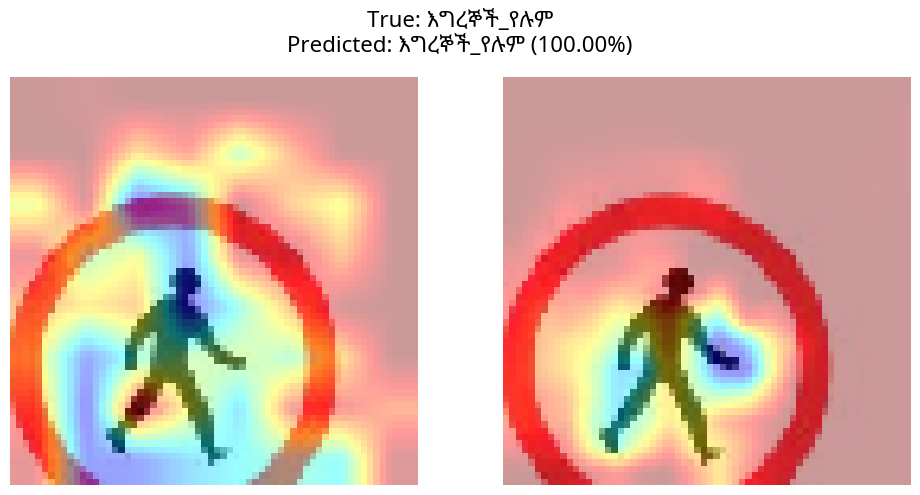

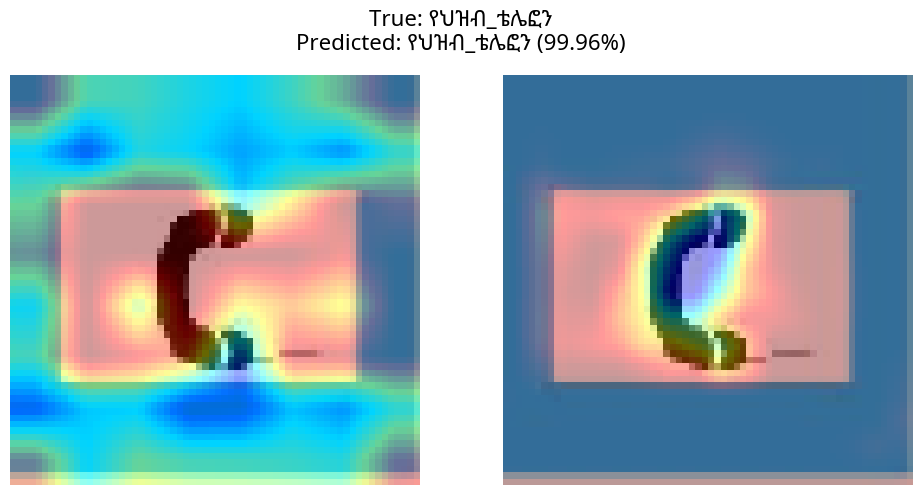

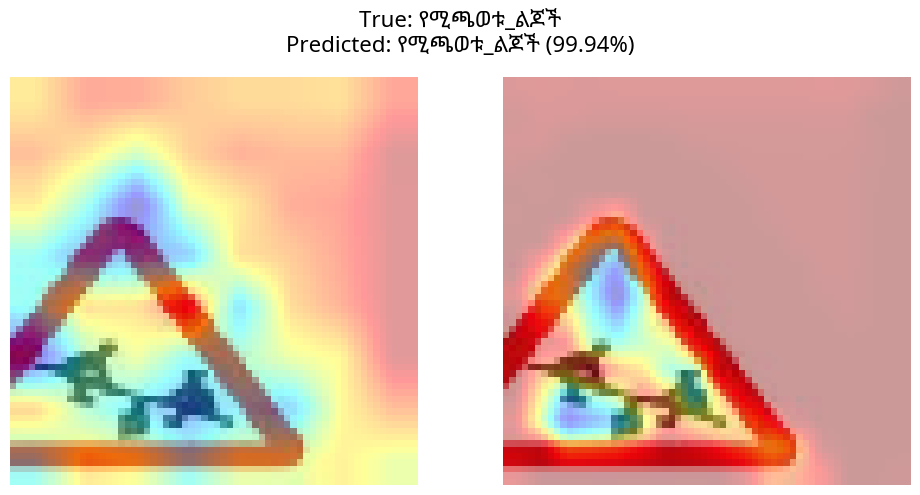

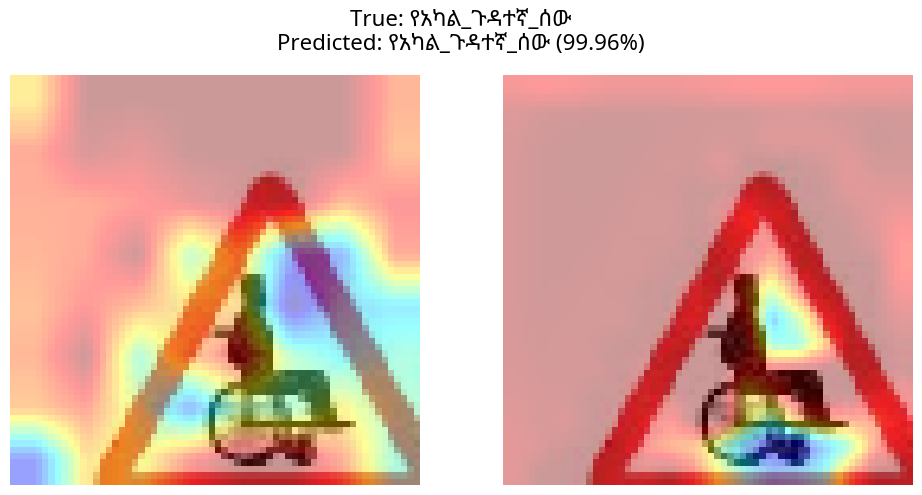

In [ ]:
num_images = 8

for i in range(num_images):
    run_gradcam(
        X_test[i],
        y_test[i],
        class_labels
    )

In [ ]:
import tensorflow as tf
import numpy as np
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        class_channel = predictions[:, np.argmax(predictions[0])]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [ ]:
def overlay_heatmap(heatmap, image, alpha=0.4):

    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))

    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(image, 1-alpha, heatmap, alpha, 0)

    return superimposed_img

In [ ]:
num_images = 16

selected_images = X_test[:num_images]
selected_labels = y_test[:num_images]

print("Shape of selected_images:", selected_images.shape)

Shape of selected_images: (16, 64, 64, 3)


**GRAD-CAM for MobileNet**

In [ ]:
rows = 4
cols = 4

plt.figure(figsize=(12,12))

for i in range(num_images):

    img = selected_images[i]
    img_array = np.expand_dims(img, axis=0)

    # ===== Extract features =====
    feat = combined_features.predict([img_array, img_array], verbose=0)
    feat_sel = feat[:, selected_features]

    # ===== Prediction =====
    pred = model.predict(feat_sel, verbose=0)
    confidence = np.max(pred)*100

    pred_idx = np.argmax(pred)
    pred_class = class_labels[pred_idx]

    # ===== True label =====
    true_idx = np.argmax(selected_labels[i])
    true_class = class_labels[true_idx]

    # ===== GradCAM =====
    heatmap = make_gradcam_heatmap(
        img_array,
        mobilenet_classification_model, # Changed to mobilenet_classification_model
        "conv_pw_5_relu"
    )

    result = overlay_heatmap(
        heatmap,
        (img*255).astype("uint8")
    )

    # ===== Plot =====
    plt.subplot(rows, cols, i+1)

    color = "green" if pred_idx == true_idx else "red"

    plt.imshow(result)

    plt.title(
        f"T: {true_class}\nP: {pred_class}\nConf: {confidence:.2f}%",
        fontsize=11,
        color=color
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

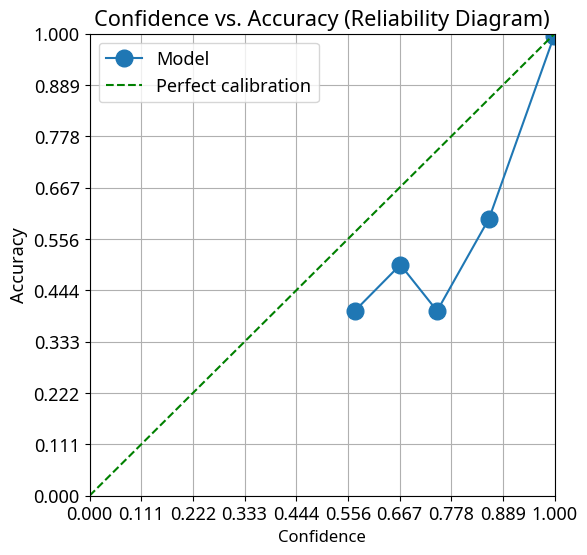

time: 148 ms (started: 2025-10-28 12:07:06 +00:00)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Bin predictions by confidence
bins = np.linspace(0, 1, 11)  # 10 bins: 0-0.1, 0.1-0.2, ..., 0.9-1.0
bin_indices = np.digitize(confidences, bins) - 1

bin_acc = []
bin_conf = []

for i in range(len(bins)-1):
    idxs = np.where(bin_indices == i)[0]
    if len(idxs) > 0:
        acc = np.mean(pred_labels[idxs] == y_test_labels[idxs])
        conf = np.mean(confidences[idxs])
        bin_acc.append(acc)
        bin_conf.append(conf)
    else:
        bin_acc.append(np.nan)  # empty bin
        bin_conf.append(np.nan)



plt.figure(figsize=(6,6))
plt.plot(bin_conf, bin_acc, marker='o',markersize=12, label='Model')
plt.plot([0,1], [0,1], linestyle='--', color='green', label='Perfect calibration')
plt.xlabel('Confidence',size=12)
plt.ylabel('Accuracy')
plt.title('Confidence vs. Accuracy (Reliability Diagram)')
plt.legend()
plt.grid(True)

# Set 10 ticks for X and Y axes
ticks = np.linspace(0, 1, 10)
plt.ylim(0, 1)
plt.xlim(0, 1)

plt.xticks(ticks)
plt.yticks(ticks)


plt.show()
